# The Machine That Predicts the Next Token
### A build-it-till-it-breaks course in the mathematics of language models

There is exactly one question a language model answers. Not "what is true," not "what should I say" — those are things we *hope* fall out. The question it literally computes is narrower and stranger:

> Given the tokens so far, what is the probability distribution over the next one?

Everything else — attention, embeddings, the training loop, the sampling knobs in an API call — is machinery for *representing that one map, fitting it to data, and drawing from it.* This course builds that machinery the way you'd actually come to understand it: not by being handed the finished definition, but by trying the obvious thing, watching it break, and letting the break tell you what the next idea has to be.

**The method, stated once.** The build chapters follow one rhythm (two deliberate exceptions flag themselves on arrival: Chapter 9 is a translation dictionary, Chapter 13 a practice and send-off):

1. **A question** you can feel, not just parse.
2. **The naive answer**, built in runnable code.
3. **The break** — you run it and watch the naive answer fail on something it should handle.
4. **The idea that repairs the break**, derived (not asserted) as the thing that *had* to come next.
5. **The forced move**: the repair leaves a new crack, which is the next chapter.

The code cells are not here to confirm arithmetic. They are where you do the breaking. Everything runs on `numpy`/`scipy`/`matplotlib` alone — no repository, no GPU, no framework — in one shared kernel, top to bottom, so you can change a line and watch a claim give way. When a cell says *predict the output before running*, do it; the gap between your prediction and the result is the lesson.

**Who this is for.** You are comfortable with linear algebra, calculus, and reading a proof. You may not yet be fluent in the *habits* of machine learning — logits, empirical risk, masking, sampling, the difference between a model class and a training procedure. Those habits are what this course installs, without hiding the algebra underneath them.

**A running example.** One four-symbol alphabet carries the whole book: the characters of the word `cat` plus a space. Every abstract claim gets checked on it by hand and in code, so no definition ever floats free of a number you can see.

> **How this notebook was made.** This is a *merged* course: it unions the build-it-till-it-breaks narrative of `99c` with the derivations-first rigor of `99_complete_college_level_walkthrough.ipynb` (numbered definitions and theorems, the variance derivation behind $\sqrt D$, an executable end-to-end model, add-one smoothing, and held-out validation). Where the two sources conflicted, external ML/math decided the call. The whole thing runs on `numpy` so every claim stays breakable.

In [1]:
# Environment: tidy numeric printing. Run this first; then top-to-bottom.
# (No forced backend: a notebook kernel's inline backend is headless-safe and
#  embeds every figure into the cell's output, so you can actually watch the plots.)
import numpy as np
np.set_printoptions(suppress=True)

> **A note on how the pieces connect.** You will meet one particular optimization problem early — *maximize expected score, but stay as spread out as possible* — and solve it. Keep the **shape** of its solution in mind. It is going to walk back on stage, uninvited, in a completely different chapter, wearing a different costume. When it does, that recurrence is the real subject of the course: a single mathematical structure that the transformer uses at three different scales. I am not going to tell you where. Watch for it.

## 0 · The one map, and why counting cannot produce it

You typed a prompt and read a reply, so it is tempting to think a model *knows continuations*: prefix in, text out, a big lookup table in the sky. Let us take that idea completely seriously — build it, in full — and see precisely where it dies. The place it dies is the shape of the hole that every later chapter is filling.

Here is the honest version of "a big table." Take a corpus. To predict the next character after some context, find every place that context occurred, and count what followed. That is not a toy of the real thing; for a fixed context length it *is* the classical n-gram language model, and for decades it was the state of the art. Let us build the bigram version over our four-symbol alphabet and ask it an innocent question.

In [2]:
import numpy as np
from collections import Counter, defaultdict

# our entire alphabet for the whole book: space, a, c, t
VOCAB = [' ', 'a', 'c', 't']
stoi  = {ch:i for i,ch in enumerate(VOCAB)}
V = len(VOCAB)

# a tiny corpus over our 4-symbol alphabet. note: no 'c' is ever followed by 't'.
corpus = "cat cat a cat tac tac"

# THE NAIVE MODEL: p(next | prev) = count(prev, next) / count(prev)
counts = defaultdict(Counter)
for prev, nxt in zip(corpus, corpus[1:]):
    counts[prev][nxt] += 1

def naive_next_dist(prev):
    c = counts[prev]; total = sum(c.values())
    return np.array([c.get(ch, 0)/total for ch in VOCAB])

print("context 'c'  ->", dict(zip(VOCAB, naive_next_dist('c').round(3))))
print("context 'a'  ->", dict(zip(VOCAB, naive_next_dist('a').round(3))))
print("context 't'  ->", dict(zip(VOCAB, naive_next_dist('t').round(3))))

context 'c'  -> {' ': 0.25, 'a': 0.75, 'c': 0.0, 't': 0.0}
context 'a'  -> {' ': 0.167, 'a': 0.0, 'c': 0.333, 't': 0.5}
context 't'  -> {' ': 0.6, 'a': 0.4, 'c': 0.0, 't': 0.0}


The distributions look reasonable. Now the innocent question. Both `c` and `t` occur all over the corpus, and the two-symbol string `ct` is a perfectly legal sequence over our alphabet — there is nothing impossible about a `t` following a `c`. What probability does the model assign to it?

In [3]:
p = naive_next_dist('c')
print("p(t | 'c') =", p[stoi['t']])

# and what does that do to the loss? the loss on a token of probability q is -log q.
q = p[stoi['t']]
print("loss if the next char really is 't':  -log(%.1f) = %s"
      % (q, "infinity" if q == 0 else round(-np.log(q), 3)))

p(t | 'c') = 0.0
loss if the next char really is 't':  -log(0.0) = infinity


There it is. The *unsmoothed maximum-likelihood* count model assigns probability **exactly zero** — and therefore **infinite loss** — to a continuation that plainly *can* happen. Name the failure precisely, because the precise version is what the rest of the book repairs:

> **The break.** The *unsmoothed MLE* n-gram estimator $\hat P(w\mid h)=\mathrm{count}(h,w)/\mathrm{count}(h)$ can only put probability on combinations it has *already seen*; everything else it declares impossible. One zero factor makes an entire sequence's probability zero and its log-likelihood $-\infty$.

Classical n-gram practice already has a patch — *smoothing* — and it genuinely repairs the zero (the next cell shows add-one smoothing turning a $0$ into $1/7$). So the honest indictment is not "counting can never assign unseen mass"; smoothing and backoff do exactly that. The indictment is subtler: smoothing only *redistributes* a fixed budget of ignorance by fiat. It never lets the model *infer* that `t` is plausible after `c` **because** `c` and `t` behave like other characters it has seen in other contexts. For that, the model must represent characters as things with **shared, transferable structure** — not as isolated table keys. A lookup table, smoothed or not, has no notion of one key being *like* another.

That single requirement — *generalize to the unseen by sharing structure* — is the entire reason the rest of this book exists. Dense parameter sharing (embeddings, attention, MLPs) is a strictly more flexible way to generalize than taxing counts. So we stop trying to store the map and start trying to *compute* it, with a parameterized function smooth enough to bend probability toward strings it never saw.

**The classical repair, worked once (add-one smoothing).** Before neural sharing, the standard fix for the zero was *smoothing*, and it is worth seeing it actually repair a zero so the Chapter-0 break is stated fairly. Take a six-word vocabulary $\{\texttt{the},\texttt{cat},\texttt{sat},\texttt{ran},\texttt{dog},\texttt{.}\}$ and the corpus `the cat sat . the cat ran . the dog sat .`. Counting gives $\hat P(\texttt{ran}\mid\texttt{dog})=0/1=0$ — the same catastrophe. Add-one smoothing pretends every continuation was seen once more:

$$
\hat P_{+1}(w\mid \texttt{dog})=\frac{\mathrm{count}(\texttt{dog},w)+1}{\mathrm{count}(\texttt{dog})+V}
\ \Rightarrow\ \hat P_{+1}(\texttt{ran}\mid\texttt{dog})=\frac{0+1}{1+6}=\frac17\approx0.143,
$$

and the price is visible in the same row: the seen continuation $\hat P(\texttt{sat}\mid\texttt{dog})$ falls from $1$ to $2/7\approx0.286$. Smoothing does not create probability; it *taxes observed events to fund unobserved ones*, and the row still sums to $1$. This is exactly why the honest Chapter-0 break is about the *unsmoothed* MLE, and why the deeper goal is similarity-based sharing rather than a flat tax.

In [4]:
from collections import Counter

# Add-one smoothing repairs the zero (the classical fix).
words = "the cat sat . the cat ran . the dog sat .".split()
uni = Counter(words); bi = Counter(zip(words, words[1:])); Vw = len(uni)

assert uni["the"] == 3 and bi[("the", "cat")] == 2
assert bi[("the", "cat")] / uni["the"] == 2 / 3            # P(cat | the), count-and-divide
assert bi[("dog", "ran")] / uni["dog"] == 0.0             # the zero: unsmoothed MLE
p_add1 = lambda w2, w1: (bi[(w1, w2)] + 1) / (uni[w1] + Vw)
assert abs(p_add1("ran", "dog") - 1/7) < 1e-12            # repaired: 0 -> 1/7
assert abs(p_add1("sat", "dog") - 2/7) < 1e-12            # ...and the seen event is taxed 1 -> 2/7
assert abs(sum(p_add1(w, "dog") for w in uni) - 1.0) < 1e-9   # row still sums to 1
print(f"unsmoothed P(ran|dog) = 0   ->   add-1: {1/7:.4f}   (P(sat|dog): 1 -> {2/7:.4f})")
print("smoothing redistributes a fixed budget; it does not infer that 'ran' is dog-like.")

unsmoothed P(ran|dog) = 0   ->   add-1: 0.1429   (P(sat|dog): 1 -> 0.2857)
smoothing redistributes a fixed budget; it does not infer that 'ran' is dog-like.


Before we build that function, we pin down exactly what kind of object it must be — because getting the type right now saves us from confusion in every later chapter.

The model consumes a **prefix** $x_{1:t}=(x_1,\dots,x_t)$ of tokens drawn from a finite vocabulary $\mathcal V=\{0,1,\dots,V-1\}$, and it must return a genuine probability distribution over the next token: a vector $p$ with $p_i\ge 0$ and $\sum_i p_i = 1$. That set of vectors is the **probability simplex** $\Delta^{V-1}$. Its relative interior $\mathring{\Delta}^{V-1}$ contains the strictly positive vectors. The finite-logit softmax model built in Chapter 1 lands in this interior, so the model used in this course is a map

$$
p_\theta:\ \bigcup_{t\ge 0}\mathcal V^{\,t}\ \longrightarrow\ \mathring{\Delta}^{V-1},
\qquad x_{1:t}\ \longmapsto\ p_\theta(\,\cdot\mid x_{1:t}),
$$

with $\theta$ standing for every number we get to tune. One prefix in; one distribution out.

**Is predicting one-token-at-a-time a real restriction?** *(Fine print — safe to skim on a first pass; the punchline is: no.)* The chain rule always factors a joint once conditional versions have been chosen on its positive-mass prefixes. The exact *bijection* used here needs one explicit hypothesis: for fixed $T$, any **strictly positive** distribution over full sequences factors, with no approximation, into strictly positive next-token conditionals:

$$
P(x_{1:T}) \;=\; \prod_{t=1}^{T} p(x_t\mid x_{<t}).
$$

This is the chain rule of probability, $P(A,B,C)=P(A)P(B\mid A)P(C\mid A,B)$, run to the end. Strict positivity makes every prefix denominator nonzero, so the joint determines every conditional; conversely, any family valued in $\mathring{\Delta}^{V-1}$ defines a strictly positive joint by the product. That is the precise bijection. If a joint has zeros, the factorization still exists, but conditionals after a zero-probability prefix are arbitrary and the joint does **not** determine them uniquely. Thus next-token factorization loses nothing within the strictly positive family produced by finite-logit softmax. The real modeling choice is the one forced above: a **single** function $p_\theta$, with shared parameters, computes every conditional from its prefix. The chain rule makes those conditionals sufficient to specify the joint; parameter sharing makes statistical transfer across prefixes possible, but does not by itself guarantee generalization.

Taking logs turns the product into a sum, which is why one sentence becomes many training signals:

$$
\log P(x_{1:T}) \;=\; \sum_{t=1}^{T}\log p_\theta(x_t\mid x_{<t}).
$$

A length-$T$ string is $T$ separate "was the next token likely?" questions. Let us watch all three of them on `cat`.

In [5]:
# Worked by hand, then in code: the chain rule on "cat".
# Suppose some model emits these three conditionals along the way:
p_c        = 0.4     # p(c   | <start>)
p_a_give_c = 0.5     # p(a   | c)
p_t_give_ca= 0.6     # p(t   | ca)

joint = p_c * p_a_give_c * p_t_give_ca
nll   = -(np.log(p_c) + np.log(p_a_give_c) + np.log(p_t_give_ca))
print(f"P('cat')            = {p_c} x {p_a_give_c} x {p_t_give_ca} = {joint:.4f}")
print(f"-log P('cat')       = {nll:.4f} nats   (a SUM of three per-token surprises)")
print(f"per-token average   = {nll/3:.4f} nats")
print(f"perplexity          = e^avg = {np.exp(nll/3):.4f}   "
      f"(as uncertain as a fair choice among ~{np.exp(nll/3):.1f} options)")

P('cat')            = 0.4 x 0.5 x 0.6 = 0.1200
-log P('cat')       = 2.1203 nats   (a SUM of three per-token surprises)
per-token average   = 0.7068 nats
perplexity          = e^avg = 2.0274   (as uncertain as a fair choice among ~2.0 options)


One string, three supervised terms, one scalar to minimize. That scalar — the average negative log-likelihood of the tokens that actually came next — is the number every training curve in this book plots. We have the *type* of the object and the *shape* of its training signal. What we do **not** have is the machine: something that turns a prefix into that probability vector while sharing structure across contexts, so that `t`-after-`c` can be judged plausible without ever having been counted.

**Self-checks (Ch 0).** (a) Why does a single zero conditional make an entire sequence's log-likelihood $-\infty$? (b) From the three conditionals above, verify by hand that the perplexity equals $(1/0.12)^{1/3}$. (c) Name the thing add-one smoothing can never do that parameter sharing can — and where in this chapter that distinction was drawn.

**Where we stand.** The object is pinned: a map from prefixes to distributions, and one scalar — average surprise — to minimize. That machine is built from real-valued scores and one specific function that turns scores into probabilities. Meet the function — and, quietly, the shape you were told to watch for.

## 1 · Scores, the simplex, and a suspiciously optimal detour

Our machine will, at the end, produce $V$ real numbers per position — one **score** per vocabulary item, called *logits*. Nothing constrains them: a logit can be $-3.2$ or $17$. But the output must live in the simplex. So we need a map $\mathbb R^V\to\Delta^{V-1}$ that is (i) always positive, (ii) sums to one, and (iii) smooth, because we intend to move the scores by gradient descent and a smooth map keeps that analysis clean (non-smoothness is not fatal — ReLU is non-differentiable at $0$ yet trains fine via subgradients — but smoothness spares us the caveats).

The obvious construction: exponentiate to force positivity, then normalize.

$$
\sigma(z)_i \;=\; \frac{e^{z_i}}{\sum_j e^{z_j}}.
$$

This is **softmax**. It is easy to write it off as an arbitrary squashing choice among many. It is not arbitrary at all, and showing why is our first real derivation — the detour promised above. First, build it and feel its two essential behaviors.

In [6]:
import numpy as np

def softmax(z, tau=1.0):
    z = np.asarray(z, float) / tau
    z = z - z.max()                 # shift for numerical safety (justified below)
    e = np.exp(z)
    return e / e.sum()

z = np.array([2.0, 1.0, 0.1, -1.0])   # four raw scores

# behavior 1: it is a genuine distribution
p = softmax(z)
print("softmax(z)      =", p.round(4), " sum =", p.sum().round(6))

# behavior 2: adding a constant to ALL scores changes nothing
print("softmax(z + 100)=", softmax(z + 100).round(4), " (identical)")

softmax(z)      = [0.6381 0.2347 0.0954 0.0318]  sum = 1.0
softmax(z + 100)= [0.6381 0.2347 0.0954 0.0318]  (identical)


The second behavior is not a curiosity; it is a theorem with teeth. Since $\sigma(z+c\mathbf 1)=\sigma(z)$ for any constant $c$, **only differences between logits carry meaning** — a token's absolute score is unobservable, and logit *differences* are exactly log-odds ratios. That same invariance is what makes the numerically stable implementation legal: subtracting $\max_j z_j$ (as the code does) changes no probability but keeps every exponent $\le 1$, so nothing overflows.

Now the detour. Instead of accepting softmax because it works, let us ask a question with no reference to exponentials at all, and see what falls out.

> Among **all** distributions $p$ on $\mathcal V$, suppose we want one that puts weight where the scores $z$ are high — it should make $\langle p, z\rangle$ large — but we do **not** want it to collapse onto the single best item, because a prefix usually has several plausible continuations. We want it as *undecided* as possible while still respecting the scores. Undecidedness has a precise measure: the Shannon entropy $H(p) = -\sum_i p_i\log p_i$, maximal at uniform, zero at a spike.

So we ask for the distribution that maximizes a weighted sum of *score-seeking* and *spread*:

$$
\max_{p\in\Delta^{V-1}}\ \Big\{\ \langle p, z\rangle \;+\; \tau\,H(p)\ \Big\},\qquad \tau>0.
$$

This problem knows nothing about softmax. Let us solve it numerically — a real constrained optimization over the simplex — and compare the answer to $\sigma(z/\tau)$.

In [7]:
from scipy.optimize import minimize
import warnings

def entropy(p):
    p = np.clip(p, 1e-12, 1)
    return -(p*np.log(p)).sum()

def solve_maxent(z, tau):
    # maximize <p,z> + tau*H(p) over the simplex, by brute-force constrained optimization
    z = np.asarray(z, float); V = len(z)
    obj  = lambda p: -(p @ z + tau*entropy(p))          # minimize the negative
    cons = ({'type':'eq', 'fun': lambda p: p.sum()-1},)
    bnds = [(1e-9, 1)]*V
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Values in x were outside bounds during a minimize step", category=RuntimeWarning)
        res = minimize(obj, x0=np.ones(V)/V, bounds=bnds, constraints=cons,
                       method='SLSQP', options={'ftol':1e-12,'maxiter':500})
    if not res.success:
        raise RuntimeError(f"SLSQP failed: {res.message}")
    return res.x

for tau in [0.5, 1.0, 3.0]:
    p_opt = solve_maxent(z, tau)
    p_sm  = softmax(z, tau)
    assert np.allclose(p_opt, p_sm, atol=1e-5)
    print(f"tau={tau}:  max-entropy solver {p_opt.round(4)}   softmax(z/tau) {p_sm.round(4)}   "
          f"max diff {np.abs(p_opt-p_sm).max():.2e}")

tau=0.5:  max-entropy solver [0.8619 0.1166 0.0193 0.0021]   softmax(z/tau) [0.8619 0.1166 0.0193 0.0021]   max diff 4.59e-08
tau=1.0:  max-entropy solver [0.6381 0.2347 0.0954 0.0318]   softmax(z/tau) [0.6381 0.2347 0.0954 0.0318]   max diff 2.10e-07
tau=3.0:  max-entropy solver [0.3824 0.274  0.203  0.1407]   softmax(z/tau) [0.3824 0.274  0.203  0.1407]   max diff 5.97e-09


They agree to solver tolerance, at every temperature. Softmax was never an ad-hoc squashing function: **softmax at temperature $\tau$ is the exact, unique answer to "seek high scores, stay as spread out as you can."** (The proof is a one-line Lagrangian: stationarity of $\langle p,z\rangle+\tau H(p)-\mu(\sum p_i-1)$ gives $z_i-\tau(\log p_i+1)+\mu=0$, i.e. $p_i\propto e^{z_i/\tau}$. Strict concavity of $H$ makes the critical point the unique maximum.)

$\tau$ is a genuine temperature. Small $\tau$ lets the score term dominate — the distribution sharpens toward the top-scoring token. Large $\tau$ lets entropy win — it flattens toward uniform. Watch the same scores $z$ resolve differently as we turn the dial.

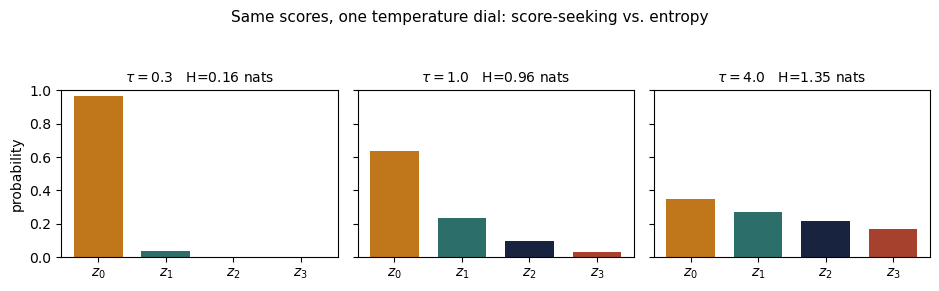

In [8]:
import matplotlib.pyplot as plt
bar_colors = ["#C0761B", "#2C6E6A", "#17233F", "#A6412E"]

taus = [0.3, 1.0, 4.0]
fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.7), sharey=True)
for ax, tau in zip(axes, taus):
    p = softmax(z, tau)
    ax.bar(range(len(z)), p, color=bar_colors, width=0.72)
    ax.set_title(f"$\\tau={tau}$   H={entropy(p):.2f} nats", fontsize=10)
    ax.set_xticks(range(len(z))); ax.set_xticklabels(['$z_0$','$z_1$','$z_2$','$z_3$'])
    ax.set_ylim(0,1)
axes[0].set_ylabel("probability")
fig.suptitle("Same scores, one temperature dial: score-seeking vs. entropy", y=1.06, fontsize=11)
plt.tight_layout(); plt.show()

Hold that flag in the ground. We asked *seek-high-scores-but-stay-spread-out* over the vocabulary, and softmax answered. Nothing here says the "items" being scored have to be words. Remember the shape of this solution.

### From a distribution to a single number to a direction

Softmax gives us $p_\theta(\cdot\mid x_{<t})$. Training needs a scalar to push downhill. From Chapter 0, that scalar is the negative log-probability of the token that actually occurred — **cross-entropy** against the one-hot truth $e_y$:

$$
\ell(z, y) \;=\; -\log \sigma(z)_y \;=\; -z_y + \log\!\sum_j e^{z_j}.
$$

The second form is worth staring at: the loss is *the true token's own score, subtracted from a soft maximum of all scores*. It is small exactly when $z_y$ is the largest logit by a comfortable margin. And its gradient — the direction training actually moves — is the cleanest object in the whole subject.

In [9]:
def cross_entropy(z, y):
    z = np.asarray(z, float)
    return -z[y] + np.log(np.exp(z - z.max()).sum()) + z.max()   # stable -z_y + logsumexp

def ce_grad_analytic(z, y):
    p = softmax(z)
    p[y] -= 1.0            # the whole gradient: p - e_y
    return p

# verify the analytic gradient against finite differences
y = 2                      # pretend the true next token is index 2
g_analytic = ce_grad_analytic(z.copy(), y)
g_numeric  = np.zeros_like(z); h = 1e-6
for i in range(len(z)):
    zp = z.copy(); zp[i]+=h; zm = z.copy(); zm[i]-=h
    g_numeric[i] = (cross_entropy(zp,y) - cross_entropy(zm,y))/(2*h)

print("analytic  dL/dz = p - e_y =", g_analytic.round(4))
print("numerical dL/dz          =", g_numeric.round(4))
print("max difference           =", np.abs(g_analytic-g_numeric).max())

analytic  dL/dz = p - e_y = [ 0.6381  0.2347 -0.9046  0.0318]
numerical dL/dz          = [ 0.6381  0.2347 -0.9046  0.0318]
max difference           = 1.6264678492916573e-10


In [10]:
# Worked Examples 1.1 / 1.2 — stable softmax, CE, and p-e_y digit by digit.
z_exact = np.array([2.0, 0.0, -1.0, 1.0])
p_exact = softmax(z_exact)
expected_p = np.array([0.6439, 0.0871, 0.0321, 0.2369])
A_exact = z_exact.max() + np.log(np.exp(z_exact - z_exact.max()).sum())
loss_exact = A_exact - z_exact[3]
grad_exact = p_exact.copy(); grad_exact[3] -= 1.0
expected_grad = np.array([0.6439, 0.0871, 0.0321, -0.7631])
assert np.allclose(p_exact, expected_p, atol=5e-5)
assert abs(loss_exact - 1.4402) < 5e-5
assert np.allclose(grad_exact, expected_grad, atol=5e-5)
assert abs(grad_exact.sum()) < 1e-12
print("p        =", p_exact.round(4).tolist())
print("loss     =", round(float(loss_exact), 4), "nats")
print("gradient =", grad_exact.round(4).tolist(), " (sums to 0)")

p        = [0.6439, 0.0871, 0.0321, 0.2369]
loss     = 1.4402 nats
gradient = [0.6439, 0.0871, 0.0321, -0.7631]  (sums to 0)


$$\boxed{\ \nabla_z\,\ell(z,y) \;=\; \sigma(z) - e_y \;=\; p - \text{truth}\ }$$

The gradient is *predicted-minus-observed*. For a next-token model trained with one-hot softmax cross-entropy — the standard pretraining and supervised-fine-tuning objective — every backpropagation step begins with exactly this vector: the model's current probabilities, minus a one at the token that really came next. Two honest qualifications keep the universal ring from misleading: against a *soft* target distribution $q$ (e.g. label smoothing) the logit gradient generalizes to $p-q$; and objectives that are **not** one-hot token cross-entropy start elsewhere — the DPO alignment loss in Chapter 11, for instance, differentiates a logistic function of policy log-ratios, not $p-e_y$. Within the token-CE objective, though, learning is that simple at the output: where the model over-weighted a token the gradient pushes that logit down, where it under-weighted the truth it pushes up, and everything upstream is the chain rule carrying this signal backward.

### The loss has a floor: cross-entropy = entropy + KL

One identity is worth keeping close, because it says what a low loss can and cannot mean. For a target distribution $q$ and model $p=\sigma(z)$, cross-entropy decomposes as

$$
H(q,p) = -\sum_i q_i\log p_i = H(q) + \mathrm{KL}(q\,\|\,p),\qquad \mathrm{KL}(q\|p)=\sum_i q_i\log\frac{q_i}{p_i}\ge 0.
$$

For a one-hot target $q=e_y$ this is exactly our loss $\ell=-\log p_y$. Taking the population version (average over the true next-token distribution $q(\cdot\mid x_{<t})$) gives

$$
R(\theta)=\mathbb E\big[-\log p_\theta(x_t\mid x_{<t})\big]=\underbrace{\mathbb E\,H\big(q(\cdot\mid x_{<t})\big)}_{\text{irreducible entropy floor}}+\underbrace{\mathbb E\,\mathrm{KL}\big(q\,\|\,p_\theta\big)}_{\ge 0,\ =0\iff p_\theta=q}.
$$

So the population minimum is exactly the expected conditional entropy. It **may be zero for deterministic conditionals** and is strictly positive only when the true next-token conditional has positive entropy. Likewise, a sufficiently flexible model can approach perplexity 1 on a finite memorized training corpus; a positive held-out or population floor requires genuinely non-deterministic continuation uncertainty. Training reduces the KL term, while tokenization changes the conditional distribution whose entropy supplies the floor. Verify the decomposition numerically.

In [11]:
import numpy as np
# H(q,p) = H(q) + KL(q||p), verified on a random target q and model p=softmax(z)
r = np.random.default_rng(3)
q = r.random(4); q = q / q.sum()               # a target distribution
z = r.normal(size=4); p = softmax(z)           # model distribution
H_q   = -(q * np.log(q)).sum()
KL    = (q * np.log(q / p)).sum()
H_qp  = -(q * np.log(p)).sum()
assert abs(H_qp - (H_q + KL)) < 1e-12 and KL >= 0
print(f"H(q,p)={H_qp:.4f}  =  H(q)={H_q:.4f} + KL(q||p)={KL:.4f}   (KL>=0: cross-entropy floors at H(q))")

# self-check: for a one-hot target the floor is 0 and a perfect model attains loss 0
ey = np.eye(4)[2]
assert abs(-(ey*np.log(np.clip(ey,1e-12,1))).sum()) < 1e-9
print("one-hot target: H(q)=0, so a perfect model reaches loss 0; any real (non-deterministic) q floors above 0.")

H(q,p)=1.9425  =  H(q)=1.1461 + KL(q||p)=0.7964   (KL>=0: cross-entropy floors at H(q))
one-hot target: H(q)=0, so a perfect model reaches loss 0; any real (non-deterministic) q floors above 0.


**Self-checks (Ch 1).** (a) Show that adding the same constant to every logit leaves softmax unchanged, and find where the stable implementation uses this. (b) Why does the gradient $p-e_y$ sum to zero across the vocabulary? (c) If all logits are equal, what distribution results, and how does that match the $\tau\to\infty$ limit of the score-plus-entropy objective?

**Where we stand.** The machine so far: scores become probabilities (softmax — the unique answer to the score-plus-entropy question, and unique only for that question), probabilities become a scalar loss ($-z_y+\log\sum_j e^{z_j}$), and the loss becomes a direction ($p-e_y$) — with an entropy floor that says what a low loss can and cannot mean.

**The forced move.** We can now turn scores into probabilities, probabilities into a loss, and the loss into a direction. But we have been *given* the scores. Where do $V$ real numbers per position actually come from? They come from tokens — but tokens are symbols, and you cannot take the gradient of a symbol. The next crack is representational: to compute scores we must first turn discrete tokens into something a smooth function can act on. First we must even decide what a "token" *is*.

## 2 · Choosing the atoms

Before a model can assign probabilities over "the next token," someone must decide what a token *is*. This choice is upstream of all the mathematics: it fixes the sample space $\mathcal V$ itself. Pick characters, and `cat` is three tokens over a tiny alphabet. Pick whole words, and `cat` is one token over an enormous, ragged one. The real systems pick something in between — frequent chunks — by a greedy merging procedure (byte-pair encoding). The point for us is not the algorithm; it is that **the choice of atoms changes what the model can generalize over**, and it is made before any learning happens.

Watch the same string become different sequences — different sample spaces — under two tokenizers, and notice the tradeoff each makes.

In [12]:
text = "cat cat"

# tokenizer A: characters. small vocab, long sequences; no OOV *within its fixed inventory*
# (the break two cells down shows what happens just outside it).
char_ids = [stoi[ch] for ch in text]
print("char tokens :", char_ids, "  length", len(char_ids), "  vocab", V)

# tokenizer B: a merged unit. suppose training merged 'c','a','t' -> one symbol 'cat'.
merges = {("cat"): 4}                       # id 4 is the new chunk
vocabB = VOCAB + ["cat"]
def greedy_merge(s):
    out=[]; i=0
    while i < len(s):
        if s[i:i+3]=="cat":
            out.append(4); i+=3
        else:
            out.append(stoi[s[i]]); i+=1
    return out
merged_ids = greedy_merge(text)
print("merged tokens:", merged_ids, "  length", len(merged_ids), "  vocab", len(vocabB))

print("\nSame string. Two sample spaces. Shorter sequences (cheaper attention, Ch 4) "
      "cost a larger vocabulary and coarser atoms to generalize over.")

char tokens : [2, 1, 3, 0, 2, 1, 3]   length 7   vocab 4
merged tokens: [4, 0, 4]   length 3   vocab 5

Same string. Two sample spaces. Shorter sequences (cheaper attention, Ch 4) cost a larger vocabulary and coarser atoms to generalize over.


In [13]:
# The break, executed: this char tokenizer's inventory is only {' ', 'a', 'c', 't'}.
try:
    stoi['b']
except KeyError as e:
    print(f"encode('b') -> KeyError: {e}   (a symbol outside the training inventory has NO id)")
print()
print("'never OOV' was only ever true relative to a fixed inventory. Byte-level tokenizers")
print("escape this by construction: all 256 byte values exist, so any string is encodable.")

encode('b') -> KeyError: 'b'   (a symbol outside the training inventory has NO id)

'never OOV' was only ever true relative to a fixed inventory. Byte-level tokenizers
escape this by construction: all 256 byte values exist, so any string is encodable.


Characters keep the vocabulary tiny, but "never hit an unknown symbol" is only true relative to a fixed character inventory: a char tokenizer trained on this four-symbol alphabet still fails on a `'b'` it never saw — the cell above just watched the `KeyError` happen. Genuine coverage of arbitrary input comes from a **byte-level** alphabet — 256 possible bytes represent any string — or an explicit unknown-token policy. And characters make sequences long, which is expensive because attention cost grows with sequence length (Chapter 4). Merges shorten sequences at the price of a bigger vocabulary and atoms that share less structure. Neither is "correct"; the choice trades sequence length against vocabulary size against how much the atoms let the model transfer knowledge, and against how it handles symbols outside its training inventory.

**Where we stand.** The atoms are chosen and the sample space $\mathcal V$ is fixed — every *next-token* probability in the course lives on this alphabet.

**The forced move.** However we chose them, tokens are still integer labels — names, not quantities. Label $2$ is not "twice" label $1$; arithmetic on IDs is meaningless. Yet Chapter 1's machine needs real vectors to compute scores. So the very next thing we need is a map from *labels* to *coordinates*.

## 3 · Coordinates for symbols — and the wall they hit

A token ID is an element of a finite set with no geometry. To let a smooth function act on it, we give each ID a learnable vector: an **embedding table** $W_E\in\mathbb R^{V\times C}$, where row $i$ is the $C$-dimensional coordinate of token $i$. "Looking up an embedding" is just multiplying a one-hot vector by $W_E$ — a linear map — so the lookup is differentiable, and the coordinates get *learned* along with everything else. This is finally where "sharing structure" from Chapter 0 becomes concrete: two tokens can sit near each other in $\mathbb R^C$ and thereby behave alike, even if the corpus never placed them in the same context.

With embeddings plus Chapter 1's head, we can already build a complete, differentiable next-token model. Let us build the simplest honest one — embed the prefix, pool it, produce logits — and then ask it the question that ends the chapter.

In [14]:
rng = np.random.default_rng(0)
C = 5
W_E = rng.normal(size=(V, C))     # token embeddings (learnable, here just random)
W_U = rng.normal(size=(C, V))     # unembedding: hidden -> logits

def bag_model_logits(ids):
    # embed each token, average them, project to logits. fully differentiable.
    H = W_E[ids]                  # (t, C): one coordinate vector per prefix token
    h = H.mean(axis=0)            # (C,): pool the prefix into one summary vector
    return h @ W_U                # (V,): a score per next-token candidate

# it works, and it is smooth. feed it a prefix:
print("logits after 'ca':", bag_model_logits([stoi['c'], stoi['a']]).round(3))
print("next-token dist  :", softmax(bag_model_logits([stoi['c'], stoi['a']])).round(3))

logits after 'ca': [ 1.834 -0.354 -0.801 -2.561]
next-token dist  : [0.836 0.094 0.06  0.01 ]


It runs, and it is differentiable — a smooth *random* parameterization (once trained, nearby embeddings will tend to share fate). Whether it **generalizes** is a held-out claim we are not entitled to yet: the weights here are random and nothing has been fit. It looks like we are done with the core. Before testing that impression, put in place one piece of plumbing the training loop will need — where, exactly, the supervised pairs come from.

### Where the supervised pairs come from: label shifting

Chapters 0–2 kept saying \"the observed next token\" without building the $(x,y)$ pairs explicitly. Do it once here, while the machine still looks finished — attention and the assembled model are about to consume these targets. A length-$(T{+}1)$ token window is $T$ next-token examples at once: the **input** is the window minus its last token and the **target** is the same window shifted one position left,

$$
x=(x_1,\ldots,x_T),\qquad y=(x_2,\ldots,x_{T+1}).
$$

Thus logits have shape `(B,T,V)`, targets have shape `(B,T)`, and position $t$ is scored against $y_t=x_{t+1}$. The causal mask prevents the representation at position $t$ from reading the future input position that contains its target. This is the label-shift contract used by every later next-token loss.


In [15]:
# Worked Example — label shifting on "cat a".
ids = [stoi[c] for c in "cat a"]                 # enc("cat a") on the running vocabulary
assert ids == [2, 1, 3, 0, 1]
x, y = ids[:-1], ids[1:]                          # the whole construction: y is x shifted left by one
assert x == [2, 1, 3, 0] and y == [1, 3, 0, 1]
for t in range(len(x)):
    prefix = "".join(VOCAB[i] for i in x[:t+1]); target = VOCAB[y[t]]
    print(f"position {t+1}: prefix {prefix!r:7} -> target {target!r}")
print("One window of T+1 tokens = T supervised examples. Two cases for where a target lives:")
print(" - interior t < T-1: y_t = x_{t+1} DOES sit at future input position t+1, so the causal")
print("   mask (Ch 4) is what stops position t from reading its own answer;")
print(f" - final t = T-1: y[{len(x)-1}] = ids[{len(x)}] = {y[-1]} was dropped by x = ids[:-1] and is")
print("   not in the input tensor at all (it is simply the next token beyond the window).")

position 1: prefix 'c'     -> target 'a'
position 2: prefix 'ca'    -> target 't'
position 3: prefix 'cat'   -> target ' '
position 4: prefix 'cat '  -> target 'a'
One window of T+1 tokens = T supervised examples. Two cases for where a target lives:
 - interior t < T-1: y_t = x_{t+1} DOES sit at future input position t+1, so the causal
   mask (Ch 4) is what stops position t from reading its own answer;
 - final t = T-1: y[3] = ids[4] = 1 was dropped by x = ids[:-1] and is
   not in the input tensor at all (it is simply the next token beyond the window).


Plumbing done — the machine has data to train on. Now the question that brings the whole edifice down. Language is about *order*: `"the cat"` and `"cat the"` are different. Does our model know that? Feed it a prefix and its reversal.

In [16]:
ca = [stoi['c'], stoi['a']]     # "ca"
ac = [stoi['a'], stoi['c']]     # "ac"

print("dist after 'ca':", softmax(bag_model_logits(ca)).round(4))
print("dist after 'ac':", softmax(bag_model_logits(ac)).round(4))
print("identical? ", np.allclose(bag_model_logits(ca), bag_model_logits(ac)))

dist after 'ca': [0.836  0.0937 0.0599 0.0103]
dist after 'ac': [0.836  0.0937 0.0599 0.0103]
identical?  True


**Identical.** The model cannot tell `"ca"` from `"ac"` — and it never will, no matter how long we train it, because the flaw is in the *function class*, not the parameters. The culprit is `mean(axis=0)`: averaging is symmetric, so the pooled summary is a function of the prefix's *multiset* of tokens, blind to their order. Any per-token-then-pool architecture has this disease. This is the indictment, made visible:

> **The break.** Every operation we have built so far treats positions independently and then combines them symmetrically. Such a model is provably order-blind: its next-token distribution depends only on *which* tokens appeared, never *in what arrangement*. For language that is not a limitation, it is a disqualification.

**Where we stand.** The machine so far: tokens have coordinates, supervised pairs exist, everything is differentiable — and the map still cannot condition on arrangement.

Repairing it requires an operation with two new powers at once: it must let one position's representation **depend on the specific other positions** present (so context can actually condition the prediction), and the whole thing must **stop being symmetric under reordering** (so arrangement matters). The first power is a mechanism for one position to read another. The second is a way to inject *where* each token sits. Note what the break does and does not force: it rules out *symmetric* combination, not every alternative — recurrence and convolution also deliver both powers, and ran the field for years. Among those options, this course chooses attention because it combines content-adaptive pairwise routing with a short path between each receiver and every causally allowed source while computing all positions in parallel during training. Those are engineering advantages, not a uniqueness theorem: a full-receptive-field causal convolution or another global parallel mixer can also provide direct all-prefix dependence and parallelism, with different parameter-sharing and routing trade-offs. The next chapter builds that chosen operation — and it is where the shape you were told to watch for comes back.

## 4 · Attention: one position reads another

We need an operation where position $t$ builds its summary by *selectively reading* the earlier positions, weighting them by relevance rather than averaging them blindly. The design almost writes itself once you name the roles. Each position emits three projections of its own vector:

- a **query** $q_t$ — what this position is looking for;
- a **key** $k_s$ — what position $s$ advertises, for matching;
- a **value** $v_s$ — what position $s$ contributes if selected.

Relevance of source $s$ to receiver $t$ is the alignment $q_t\!\cdot\!k_s$. Turn each receiver's row of alignments into weights that sum to one, and mix the values by those weights. "Turn scores into weights that sum to one" — Chapter 1 already handed us a principled way to do exactly that, unique for its score-plus-entropy objective. The whole operation is:

$$
a_{t,s}=\frac{q_t\cdot k_s}{\sqrt D},\qquad
w_{t,\cdot}=\mathrm{softmax}(a_{t,\cdot}),\qquad
o_t=\sum_{s} w_{t,s}\,v_s .
$$

The $\sqrt D$ is a temperature — and the next section *derives* its value from a variance argument rather than asserting it. Causality — position $t$ may only read $s\le t$ — is imposed by adding $-\infty$ to the forbidden scores before the softmax, so their weight is exactly zero. Build it in a dozen lines of numpy and run it on three fixed `"cat"` residual vectors chosen so you can check every number by hand.

### Why divide by $\sqrt D$ — the variance derivation (not an asserted constant)

The temperature $\sqrt D$ is forced by a variance argument. **Lemma (dot-product variance).** If $q,k\in\mathbb R^D$ have independent, zero-mean, unit-variance coordinates, then $\mathbb E[q\cdot k]=0$ and $\mathrm{Var}(q\cdot k)=D$, so $\mathrm{Var}\!\big((q\cdot k)/\sqrt D\big)=1$. *Proof sketch:* each term $q_rk_r$ has mean $0$ and variance $\mathbb E[q_r^2]\mathbb E[k_r^2]=1$; distinct terms are uncorrelated, and variances of $D$ uncorrelated unit-variance terms add to $D$.

These hypotheses are an **initialization model**, not a theorem about trained networks: at initialization, projections of normalized activations approximately satisfy them, and after training the distributions drift. The design consequence is what matters: unscaled scores have standard deviation $\sqrt D$, so without the $1/\sqrt D$ factor a wider head would start at effectively lower temperature — near-argmax rows whose softmax Jacobian $\mathrm{diag}(w)-ww^\top$ is nearly zero, killing gradients. Dividing by $\sqrt D$ keeps the initial score scale, and hence the initial row entropy, independent of head width.

**Production shapes (what the toy elides).** A real implementation carries a batch and heads. The residual stream $(B,T,C)$ is projected to $Q,K,V$ and split into $H$ heads of width $D=C/H$, giving $(B,H,T,D)$; scores are $(B,H,T,T)$ with the row-softmax on the **source-position axis** (the last one); the per-head outputs $(B,H,T,D)$ are concatenated back to $(B,T,C)$ and mixed by an output projection $W_O$. Verify the variance claim, then the shapes, in numpy.

In [17]:
import numpy as np
_rng = np.random.default_rng(0)

# Lemma: Var(q.k) = D at unit-variance init, so dividing by sqrt(D) restores unit variance.
for D_ in [8, 64, 256]:
    Q = _rng.normal(size=(20000, D_)); K = _rng.normal(size=(20000, D_))
    dots = (Q * K).sum(1)
    print(f"D={D_:>4}: Var(q.k) = {dots.var():8.2f}  (~D)     Var((q.k)/sqrt(D)) = {(dots/np.sqrt(D_)).var():.3f}  (~1)")

# Production shape contract for batched multi-head causal attention.
B, T, C, H = 2, 5, 12, 3; Dh = C // H
X = _rng.normal(size=(B, T, C))
Wq = _rng.normal(size=(C, C)); Wk = _rng.normal(size=(C, C)); Wv = _rng.normal(size=(C, C)); Wo = _rng.normal(size=(C, C))
def split_heads(A): return A.reshape(B, T, H, Dh).transpose(0, 2, 1, 3)   # (B,T,C) -> (B,H,T,D)
Qh, Kh, Vh = split_heads(X @ Wq), split_heads(X @ Wk), split_heads(X @ Wv)
scores = Qh @ Kh.transpose(0, 1, 3, 2) / np.sqrt(Dh)                       # (B,H,T,T)
mask = np.triu(np.full((T, T), -np.inf), k=1)
w = np.exp(scores + mask - (scores + mask).max(-1, keepdims=True))
w = w / w.sum(-1, keepdims=True)                                          # row-softmax on SOURCE axis
ctx = (w @ Vh).transpose(0, 2, 1, 3).reshape(B, T, C) @ Wo               # concat heads -> (B,T,C) -> W_O
print(f"\nshapes  X {X.shape} -> Q/K/V heads {Qh.shape} -> scores {scores.shape} -> out {ctx.shape}")
assert scores.shape == (B, H, T, T) and ctx.shape == (B, T, C)
assert np.allclose(w[..., :].sum(-1), 1.0) and np.allclose(np.triu(w[0, 0], 1), 0)   # rows sum to 1; causal
print("row-softmax normalizes the last (source-position) axis; future positions are exactly zero.")

D=   8: Var(q.k) =     8.19  (~D)     Var((q.k)/sqrt(D)) = 1.023  (~1)
D=  64: Var(q.k) =    64.37  (~D)     Var((q.k)/sqrt(D)) = 1.006  (~1)


D= 256: Var(q.k) =   257.04  (~D)     Var((q.k)/sqrt(D)) = 1.004  (~1)

shapes  X (2, 5, 12) -> Q/K/V heads (2, 3, 5, 4) -> scores (2, 3, 5, 5) -> out (2, 5, 12)
row-softmax normalizes the last (source-position) axis; future positions are exactly zero.


In [18]:
def softmax_rows(A):
    A = A - A.max(axis=-1, keepdims=True)
    E = np.exp(A)
    return E / E.sum(axis=-1, keepdims=True)

def attention(X, W_Q, W_K, W_V, causal=True):
    Q, K, Vv = X @ W_Q, X @ W_K, X @ W_V
    T, D = Q.shape
    scores = (Q @ K.T) / np.sqrt(D)                     # (T,T) alignments, temperature sqrt(D)
    if causal:
        scores = scores + np.triu(np.full((T,T), -np.inf), k=1)   # forbid reading the future
    W = softmax_rows(scores)                            # each row: a distribution over sources
    return W @ Vv, W

# the "cat" residual toy: three token vectors in R^2
X   = np.array([[1.1, 0.5], [0.5, -0.4], [-0.6, 1.0]])
W_K = np.array([[0.0, 1.0], [1.0, 0.0]])                # swap coordinates
I   = np.eye(2)
out, W = attention(X, W_Q=I, W_K=W_K, W_V=I, causal=True)

np.set_printoptions(suppress=True)
print("attention weights W (row t = how position t reads positions 1..t):")
print(W.round(4))
print("\nrow sums:", W.sum(1).round(4), " (each row is a probability distribution)")
print("output o_3 =", out[2].round(4))

attention weights W (row t = how position t reads positions 1..t):
[[1.     0.     0.    ]
 [0.5371 0.4629 0.    ]
 [0.4542 0.4354 0.1104]]

row sums: [1. 1. 1.]  (each row is a probability distribution)
output o_3 = [0.6511 0.1634]


Read the weight matrix as the mechanism it is. It is **lower-triangular** — every future position has weight zero, exactly the causal constraint. Each **row sums to one** — it is a distribution over the allowed prefix. Row 1 has no choice (it can only read itself); row 3 spreads its attention across all three earlier positions. This matrix *is* the context-conditioning we were missing in Chapter 3: it is data-dependent (it changes with the tokens) and it is not a fixed average.

Two structural facts, each with a one-line proof you can now run.

**A single head's output is a convex combination of the values *it* reads.** Since row $t$ is nonnegative and sums to one over $s\le t$, $o_t=\sum_{s\le t}w_{t,s}v_s$ lies in the convex hull of $\{v_1,\dots,v_t\}$ — here, with $W_V=I$, the value vectors are the input rows themselves. A single head can *route and blend* prefix information but cannot leave the hull of those value vectors. Leaving that hull is done by the value/output projections, multiple heads, the residual add, **and** the MLP together (Chapter 5) — not by the MLP alone; the demo there separates their roles.

In [19]:
# o_3 must lie in the convex hull of v_1, v_2, v_3 (here V=I so values are the X rows).
vals = X
coeffs = W[2]                                   # the row-3 weights
print("o_3 rebuilt as sum_s w_3s v_s :", (coeffs[:,None]*vals).sum(0).round(4))
print("matches attention output      :", out[2].round(4))
print("weights nonneg & sum to 1     :", (coeffs>=0).all(), round(coeffs.sum(),6))

o_3 rebuilt as sum_s w_3s v_s : [0.6511 0.1634]
matches attention output      : [0.6511 0.1634]
weights nonneg & sum to 1     : True 1.0


**Unmasked attention is order-blind, and a position signal is the clean fix.** Remove the causal mask and *permute the input positions*: plain attention's output permutes the same way and nothing else changes — it sees only the *multiset* of tokens. Add a distinct per-position vector — a **position embedding** — and reordering now changes the result. Watch the symmetry hold, then shatter. (The experiment isolates the *unmasked* case, where the equivariance is exact; the precise strength of the claim, and the two caveats that keep it honest, follow the run.)

In [20]:
perm = [2, 0, 1]                                  # some reordering of the 3 positions

# (a) plain attention, no positions, no mask: permuting input just permutes output
out_plain, _  = attention(X,        I, W_K, I, causal=False)
out_perm,  _  = attention(X[perm],  I, W_K, I, causal=False)
print("unmasked, no positions -> permutation-equivariant :",
      np.allclose(out_perm, out_plain[perm]))     # True: order is invisible

# (b) add distinct position vectors, then attend: order now changes the result
P = np.array([[0.9, -0.2], [-0.1, 0.7], [0.3, 0.3]])   # one vector per slot
out_pos,  _   = attention(X + P,          I, W_K, I, causal=False)
out_pos_p, _  = attention(X[perm] + P,    I, W_K, I, causal=False)   # tokens moved, slots fixed
print("with position signal   -> reordering changes output:",
      not np.allclose(out_pos_p, out_pos[perm]))    # True: the symmetry is broken

unmasked, no positions -> permutation-equivariant : True
with position signal   -> reordering changes output: True


That is the whole story of position embeddings in two `print`s — but state the theorem at exactly the strength it holds. **Unmasked** attention composed with positionwise maps is permutation-*equivariant*: permute the input rows and the output permutes the same way (proof: under a permutation matrix $P$ the scores transform by conjugation $PQK^\top P^\top$, and row-softmax commutes with simultaneous row/column permutation, so $W\mapsto PWP^\top$ and $WV\mapsto P\,WV$). Such a stack sees only the *multiset* of tokens, never their arrangement — that is the precise sense in which bare unmasked attention is order-blind.

Two caveats keep this honest, because the naive version ("a causal transformer can't represent order without position embeddings") is false:

- The **causal mask is not** invariant under arbitrary position permutations — it is itself an asymmetric source of order information. So $\mathrm{Attn}_{\text{causal}}$ is *not* permutation-equivariant, and a causal decoder can in fact learn position-dependent behavior from the mask alone (Haviv et al., 2022, arXiv:2203.16634).
- Explicit position embeddings are therefore not *mathematically necessary* for all causal language modeling; they are a **stronger, more direct** position signal that makes order easy to use and is standard practice.

The clean statement: adding a position signal is an explicit symmetry break for the *unmasked-equivariant* part of the machine, giving the identical machinery a direct coordinate that says *where* — the reliable way to distinguish `"the cat"` from `"cat the"`.

In [21]:
# take row 3's raw alignments (pre-softmax scores) over positions 1,2,3
Q = X @ I; Kk = X @ W_K
raw_scores_row3 = (Q @ Kk.T)[2]          # a_3s = q_3 . k_s, before scaling
D = 2; tau = np.sqrt(D)

# solve "maximize <w, a> + tau*H(w)" over the simplex on positions -- the SAME solver as Ch1
w_maxent = solve_maxent(raw_scores_row3, tau)
w_attn   = softmax(raw_scores_row3, tau)

print("attention row 3 (softmax) :", w_attn.round(4))
print("max-entropy selection     :", w_maxent.round(4))
print("same problem, same answer :", np.allclose(w_maxent, w_attn, atol=1e-4))

attention row 3 (softmax) : [0.4542 0.4354 0.1104]
max-entropy selection     : [0.4542 0.4354 0.1104]
same problem, same answer : True


The structure from the output head has walked back on stage inside the attention mechanism. **Softmax over the vocabulary and attention over positions are the same variational principle at two different scales:** *pursue the highest-scoring option, but resist collapsing to a hard choice.* At the head, the competition is among next tokens; in attention, it is among source positions; the temperature ($1$ at the head, $\sqrt D$ in attention) sets how sharp the resolution is.

State the uniqueness at exactly the strength it holds. Softmax at temperature $\tau$ is the **unique maximizer of the specific objective** $\langle w,a\rangle+\tau H(w)$ over the simplex, for $\tau>0$ (strict concavity of $H$ forces a unique optimum). It is *not* the unique differentiable relaxation of hard lookup in general — change the regularizer and the optimizer changes, and smooth alternatives such as Gumbel-softmax or sparsemax are ready counterexamples. The exact-lookup limit $\tau\to 0$ recovers a non-differentiable argmax; softmax is *the* entropy-regularized relaxation, which is the property we actually use.

This recurring structure has a name — the **Gibbs / maximum-entropy principle** — and it is not done returning. One optimization, two scales so far: choosing a token, choosing what to attend to. Keep watching.

**Self-checks (Ch 4).** (a) Prove the middle step of the equivariance argument: row-softmax commutes with simultaneous row *and* column permutation, $\mathrm{softmax}(PAP^\top)=P\,\mathrm{softmax}(A)\,P^\top$. (b) Show that adding $-\infty$ before the softmax is equivalent to zeroing the forbidden weights after it *and renormalizing* — and explain exactly what breaks if you zero without renormalizing. (c) With $W_V=I$, where must $o_t$ lie — and which parts of the coming block can move a result outside that set?

**Where we stand.** The machine so far: positions read their prefix causally, order enters through position signals, and the reading weights are themselves Gibbs rows.

**The forced move.** We now have every piece of the map: embeddings turn tokens into coordinates, attention lets positions read each other and (with position signals) respects order, the head turns the result into a distribution, and cross-entropy scores it. But a single attention head produces only convex combinations of the *values it reads* — so the next chapter assembles heads, an output projection, a feature-computing MLP, normalization, and residual connections into the repeatable **block** that, stacked, is the transformer.

## 5 · The block: new features, and surviving depth

Chapter 4 ended on a quiet limitation with large consequences: a single attention head produces only *convex combinations* of the values it reads (Proposition, run there). It can route and blend information already present in the sequence, but it can never manufacture a coordinate that was not already inside the hull of its inputs. Two questions follow, and the transformer block is precisely their joint answer:

1. If attention can only mix, what sublayer computes genuinely **new** features?
2. Real models stack dozens of these blocks. What keeps the gradient — and the signal — alive through that depth?

Let us make the limitation visible first, because seeing the wall is what justifies the door.

### The convex-hull trap, and how the block escapes it

Take a handful of value vectors in the plane, run attention over them for several layers, and plot where the outputs land. Then apply one positionwise MLP to the same points and plot *those*. Watch which operation can leave the hull.

attention outputs outside the hull:   0%   (this head, W_V=I: convex-mixes only)
MLP outputs outside the hull      :  57%   (nonlinear map: leaves the hull)


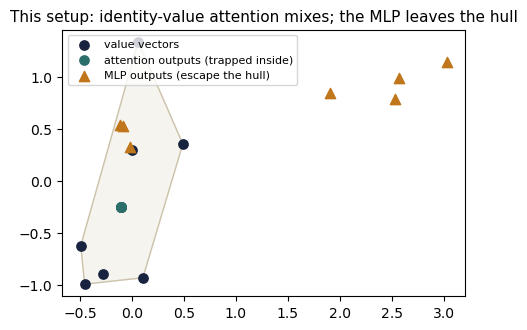

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull, Delaunay
from scipy.special import erf
INK, AMBER, TEAL, RULE = "#17233F", "#C0761B", "#2C6E6A", "#CDC3AB"

rng2 = np.random.default_rng(7)
Vpts = rng2.normal(size=(7, 2))                       # 7 value vectors in the plane

def attn_stack(X, layers):
    Wk = np.array([[0.6, 0.8], [-0.8, 0.6]])          # a fixed key rotation
    for _ in range(layers):
        X, _ = attention(X, np.eye(2), Wk, np.eye(2), causal=False)   # from Chapter 4
    return X

def gelu(u):                                           # smooth ReLU: u * standard-normal-CDF(u)
    return u * 0.5 * (1 + erf(u / np.sqrt(2)))

# a positionwise MLP: expand to width 8, GELU, project back to 2
Wm1 = rng2.normal(size=(2, 8)); bm1 = rng2.normal(size=8) * 0.4
Wm2 = rng2.normal(size=(8, 2)); bm2 = rng2.normal(size=2) * 0.4
mlp = lambda X: gelu(X @ Wm1 + bm1) @ Wm2 + bm2

hull = ConvexHull(Vpts); tri = Delaunay(Vpts)
outside = lambda P: np.mean(tri.find_simplex(P) < 0)  # fraction strictly outside the hull

attn_out, mlp_out = attn_stack(Vpts, 3), mlp(Vpts)
print(f"attention outputs outside the hull: {outside(attn_out)*100:3.0f}%   (this head, W_V=I: convex-mixes only)")
print(f"MLP outputs outside the hull      : {outside(mlp_out)*100:3.0f}%   (nonlinear map: leaves the hull)")

fig, ax = plt.subplots(figsize=(5.2, 4.3))
for s in hull.simplices: ax.plot(Vpts[s, 0], Vpts[s, 1], color=RULE, lw=1)
ax.fill(Vpts[hull.vertices, 0], Vpts[hull.vertices, 1], color=RULE, alpha=0.18)
ax.scatter(*Vpts.T, color=INK, s=45, zorder=3, label="value vectors")
ax.scatter(*attn_out.T, color=TEAL, s=45, zorder=3, label="attention outputs (trapped inside)")
ax.scatter(*mlp_out.T, color=AMBER, marker="^", s=55, zorder=3, label="MLP outputs (escape the hull)")
ax.legend(fontsize=8, loc="upper left"); ax.set_aspect("equal")
ax.set_title("This setup: identity-value attention mixes; the MLP leaves the hull", fontsize=11); plt.show()

That is the division of labor inside every transformer block — but state the hull claim precisely, because the sloppy version ("only the MLP can compute new coordinates") is false. A **single attention head** output $o_t=\sum_s w_{t,s}v_s$ is a convex combination of *that head's projected values* $v_s = X_s W_V$, so it lies in the convex hull of those value vectors. That is the exact content of the demo above (here $W_V=I$, so the values are the input rows themselves).

What is *not* confined to the input hull is a real attention **sublayer**: it has a learned value projection $W_V$ (so values already leave the input hull — take $W_V=2I$ and a point already doubles out of its own hull), multiple heads concatenated, an output projection $W_O$, and a residual add. Any of these can move the result outside the hull of the input rows. So the honest statement is: *within a single head, attention only convex-mixes its values*; the block escapes that hull through projections, multi-head concatenation, the residual path, **and** the positionwise MLP. The **MLP**'s distinct role is nonlinear, per-token channel mixing — expand to a wider hidden layer, apply GELU $\text{GELU}(u)=u\,\Phi(u)$ (a smooth mollified ReLU, $\Phi$ the standard-normal CDF), project back — not that it is the sole source of new coordinates. Without a nonlinearity the whole block would be a composition of linear maps and convex mixes, and *that* is what cannot manufacture genuinely new nonlinear features.

That addresses new features. Question 2 — depth — is where the more dangerous failure lives.

### Depth and gradients: the residual path helps, but guarantees nothing

Stack many sublayers and differentiate. By the chain rule the Jacobian of a plain composition $f_L\circ\cdots\circ f_1$ is a **product** of the individual Jacobians, and a product of matrices with norm below one shrinks *exponentially* in depth. The gradient reaching the early layers is then effectively zero — the classical vanishing-gradient death of deep networks.

The residual wiring $x\mapsto x+f(x)$ changes the algebra: its Jacobian is $I+J_f$, so a stack gives $\prod_l (I+J_{f_l}) = I + \sum_l J_{f_l} + \cdots$. The leading identity term *often* keeps a usable gradient path — but "often," not "always": this product can still vanish, explode, or be ill-conditioned (the next section gives one-line counterexamples). What the residual form reliably buys is that each sublayer can sit *near the identity* under suitable initialization, normalization, and scaling, which is what makes very deep stacks trainable *in practice*. Do not take even that on faith; measure both paths in a deliberately near-identity construction.

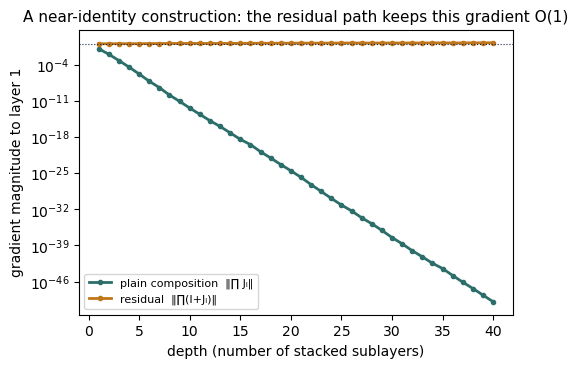

at depth 40:  plain gradient = 1.23e-50   residual gradient = 1.72e+00
ratio = 1.4e+50  -- in THIS small-Jacobian construction, residual preserves what the plain path annihilates


In [23]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL = "#17233F", "#C0761B", "#2C6E6A"

rng3 = np.random.default_rng(3)
d = 8
As = [rng3.normal(size=(d, d)) * (0.06 / np.sqrt(d)) for _ in range(40)]   # small sublayer maps

# Jacobian of the full stack, built incrementally. Plain: product of A_l. Residual: product of (I+A_l).
depths = range(1, 41)
Jp, Jr = np.eye(d), np.eye(d)
plain, resid = [], []
for l in range(40):
    Jp = As[l] @ Jp
    Jr = (np.eye(d) + As[l]) @ Jr
    plain.append(np.linalg.norm(Jp, 2))
    resid.append(np.linalg.norm(Jr, 2))

fig, ax = plt.subplots(figsize=(5.6, 3.7))
ax.semilogy(list(depths), plain, color=TEAL, lw=2, marker="o", ms=3, label="plain composition  ‖∏ Jₗ‖")
ax.semilogy(list(depths), resid, color=AMBER, lw=2, marker="o", ms=3, label="residual  ‖∏(I+Jₗ)‖")
ax.axhline(1.0, color=INK, lw=0.8, ls=":")
ax.set_xlabel("depth (number of stacked sublayers)"); ax.set_ylabel("gradient magnitude to layer 1")
ax.legend(fontsize=8); ax.set_title("A near-identity construction: the residual path keeps this gradient O(1)", fontsize=11); plt.show()

print(f"at depth 40:  plain gradient = {plain[-1]:.2e}   residual gradient = {resid[-1]:.2e}")
print(f"ratio = {resid[-1]/plain[-1]:.1e}  -- in THIS small-Jacobian construction, residual preserves what the plain path annihilates")

The correct statement first: residual wiring $x\mapsto x+f(x)$ *improves* gradient propagation by making each sublayer near-identity under suitable initialization, normalization, and residual scaling — which is what makes very deep stacks trainable *in practice*. It is not a guarantee: it does not by itself ensure stable gradients or make an arbitrary hundred-layer network trainable. The residual Jacobian is a product of factors $I+J_{f_l}$, and that product can still vanish, explode, or be ill-conditioned; the additive identity term in the formal expansion does not prevent cancellation by the other terms. Two one-line counterexamples make this concrete: a single layer with $J_f=-I$ gives $I+J_f=0$ and the gradient vanishes *exactly*; $L$ layers with $J_f=I$ give $\|\prod_l(I+J_f)\|=2^L$, which explodes.

So read the demo above for what it is — a construction, not a law. The matrices were deliberately scaled to $0.06/\sqrt d$, and in *that* small-Jacobian regime the plain gradient plunges toward machine zero while the residual gradient stays $O(1)$: the observed survival is a property of the regime, exhibited, not promised.

The residual wiring also gives the block a physical reading: $x_{l+1}=x_l+f_l(x_l)$ is the explicit Euler step of a flow $\dot x = f(x,t)$, so a deep residual network is a **discretized flow** on the space of token vectors, each vector nudged alternately by attention (coupling across positions) and the MLP (a positionwise self-interaction). If a sublayer is useless early in training it can learn $f\approx 0$ and the flow is near-identity — which is also why training can even get started.

One hazard remains, and it is *not* one residual connections fix: as depth grows, the residual stream's activation *scale* can still drift. The next ingredient — layer norm — addresses a narrower, related problem: it standardizes the *statistics each sublayer reads*, which stabilizes optimization. It is not a guarantee that activations stay bounded across depth (the next section is careful about exactly this).

### Layer norm: it puts each token vector's *statistics* on a fixed scale

Before each sublayer reads the residual stream, layer norm rescales each token vector across its channels: subtract the mean, divide by the (regularized) standard deviation, then apply learned per-channel scale and shift $\gamma,\beta$:

$$
\mathrm{LN}(u)_i=\gamma_i\,\frac{u_i-\mu(u)}{\sqrt{\sigma^2(u)+\epsilon}}+\beta_i.
$$

Its geometry, stated exactly (because the sloppy "every vector lands on one sphere, so activations can't blow up with depth" is false):

- With $\epsilon=0$ and a **nonconstant** $u$, the normalization core $N(u)=(u-\mu\mathbf 1)/\sigma$ has mean $0$ and norm exactly $\sqrt C$ — it lands on a sphere of radius $\sqrt C$ in the mean-zero hyperplane. A **constant** vector has $\sigma=0$ and is undefined (division by zero).
- With the standard $\epsilon>0$, the norm is $\|N_\epsilon(u)\|=\sqrt{C\,\mathrm{Var}(u)/(\mathrm{Var}(u)+\epsilon)}\le\sqrt C$, generally *below* the sphere, and a constant vector maps to $\mathbf 0$, not to radius $\sqrt C$.
- The learned $\gamma,\beta$ then apply an affine map, so the output is *not* confined to a fixed sphere at all.

So the correct claim is modest and true: layer norm **stabilizes the input statistics each sublayer reads** (removing per-token offset and scale before $\gamma,\beta$), which helps optimization. It does *not* by itself prevent the residual stream's magnitude from growing or collapsing across depth. Verify the core geometry — and the $\epsilon$ story — directly.

In [24]:
import numpy as np
C = 12
# normalization core with an explicit epsilon (as real LayerNorm uses); gamma=1, beta=0 here.
def normalize(u, eps=0.0):
    var = u.var()
    return (u - u.mean()) / np.sqrt(var + eps)

print(f"eps=0, nonconstant input: norm should be sqrt(C) = {np.sqrt(C):.4f}\n")
for scale, offset in [(0.01, 0.0), (1.0, 5.0), (100.0, -50.0)]:
    u = rng.normal(size=C) * scale + offset          # wildly different scale AND offset
    n = normalize(u, eps=0.0)
    print(f"  scale {scale:>6}, offset {offset:>5}:  ||N(u)|| = {np.linalg.norm(n):.4f}   mean = {n.mean():+.1e}")

print("\nTwo places the 'fixed sphere' picture breaks, exactly as the text warns:")
# (1) a CONSTANT vector: sigma=0. eps=0 gives NaN; standard eps>0 sends it to 0, not radius sqrt(C).
const = np.full(C, 3.0)
print(f"  constant vector, eps=0   -> ||N|| = {np.linalg.norm(normalize(const, 0.0)):.4f}  (NaN: undefined)")
print(f"  constant vector, eps=1e-5-> ||N|| = {np.linalg.norm(normalize(const, 1e-5)):.4f}  (maps to 0)")
# (2) with eps>0 a normal vector lands BELOW sqrt(C):
u = rng.normal(size=C)
print(f"  normal vector,   eps=1e-5-> ||N|| = {np.linalg.norm(normalize(u, 1e-5)):.4f}  (<= sqrt(C) = {np.sqrt(C):.4f})")
print("\nLayerNorm fixes the statistics each sublayer READS; it does not pin activations to one sphere,")
print("and learned gamma,beta reopen the affine directions the model needs.")

eps=0, nonconstant input: norm should be sqrt(C) = 3.4641

  scale   0.01, offset   0.0:  ||N(u)|| = 3.4641   mean = +3.7e-17
  scale    1.0, offset   5.0:  ||N(u)|| = 3.4641   mean = +1.1e-16
  scale  100.0, offset -50.0:  ||N(u)|| = 3.4641   mean = +3.7e-17

Two places the 'fixed sphere' picture breaks, exactly as the text warns:
  constant vector, eps=0   -> ||N|| = nan  (NaN: undefined)
  constant vector, eps=1e-5-> ||N|| = 0.0000  (maps to 0)
  normal vector,   eps=1e-5-> ||N|| = 3.4641  (<= sqrt(C) = 3.4641)

LayerNorm fixes the statistics each sublayer READS; it does not pin activations to one sphere,
and learned gamma,beta reopen the affine directions the model needs.


/var/folders/dp/3p2bf6rn5ts4nwyykbm8c_b40000gn/T/ipykernel_30386/3633837522.py:6: RuntimeWarning: invalid value encountered in divide
  return (u - u.mean()) / np.sqrt(var + eps)


In [25]:
import numpy as np
# Worked Example 5.1 — at C=2 the normalization core collapses every nonconstant vector to +/-(1,-1)
for row in np.array([[1.1, 0.5], [0.5, -0.4], [-0.6, 1.0]]):
    n = (row - row.mean()) / row.std()
    assert np.allclose(np.abs(n), 1.0, atol=1e-6)         # every output is +/-(1, -1)
    assert abs(n.sum()) < 1e-6 and abs(np.linalg.norm(n) - np.sqrt(2)) < 1e-6
    print(f"{[round(v,2) for v in row]}  ->  {[round(v,4) for v in n]}")
print("Two rows sharing nothing in scale land on the identical 0-dimensional sphere: at C=2, one bit per token.")
print("This is exactly why LayerNorm costs only two nuisance DOF (offset, scale) at realistic width C.")

[1.1, 0.5]  ->  [1.0, -1.0]
[0.5, -0.4]  ->  [1.0, -1.0]
[-0.6, 1.0]  ->  [-1.0, 1.0]
Two rows sharing nothing in scale land on the identical 0-dimensional sphere: at C=2, one bit per token.
This is exactly why LayerNorm costs only two nuisance DOF (offset, scale) at realistic width C.


**Worked Example (LayerNorm at $C=2$: an instructive catastrophe).** The geometry above says the normalized vector lands on a sphere of dimension $C-2$. At $C=2$ that sphere is *zero*-dimensional — just the two points $\pm(1,-1)$ — so normalization throws away everything about a token vector except which coordinate is larger. Watch two very different rows collapse to the same point, confirming the dimension count and showing why real models use wide $C$.

### Assembling the block, and watching the flow

Now compose the pieces into the pre-norm block this course targets:

$$
x' = x + \text{Attn}(\text{LN}(x)),\qquad \mathcal B(x) = x' + \text{MLP}(\text{LN}(x')),
$$

stack it, and — because we can work in the plane — literally *watch* one token vector travel through the layers. With near-identity initialization the trajectory barely moves (the flow is close to the identity map); let the sublayers act, and the residual stream bends along a path.

small residual step (Δt→0)  ->  total drift ‖x_L - x_0‖ = 1.300
large residual step         ->  total drift ‖x_L - x_0‖ = 6.194


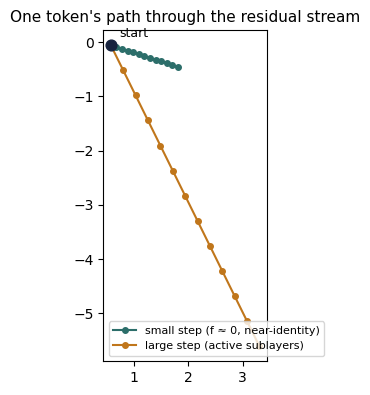

In [26]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL = "#17233F", "#C0761B", "#2C6E6A"

rng4 = np.random.default_rng(11)
T, Cc = 4, 2
def LN(X):
    return (X - X.mean(-1, keepdims=True)) / np.sqrt(X.var(-1, keepdims=True) + 1e-5)

def make_block(eps):
    Wk  = rng4.normal(size=(Cc, Cc)) * 0.9
    Wm1 = rng4.normal(size=(Cc, 4*Cc)) * 0.9; Wm2 = rng4.normal(size=(4*Cc, Cc)) * 0.9
    def block(X):
        a, _ = attention(LN(X), np.eye(Cc), Wk, np.eye(Cc), causal=True)   # LN -> attn -> add
        X = X + eps * a                                                    # eps = residual step (Euler Δt)
        X = X + eps * (gelu(LN(X) @ Wm1) @ Wm2)
        return X
    return block

X0 = rng4.normal(size=(T, Cc))
def trajectory(scale, L=12):
    blk = make_block(scale); X = X0.copy(); path = [X[-1].copy()]
    for _ in range(L):
        X = blk(X); path.append(X[-1].copy())
    return np.array(path)

near_identity, active = trajectory(0.03), trajectory(0.45)
print(f"small residual step (Δt→0)  ->  total drift ‖x_L - x_0‖ = {np.linalg.norm(near_identity[-1]-near_identity[0]):.3f}")
print(f"large residual step         ->  total drift ‖x_L - x_0‖ = {np.linalg.norm(active[-1]-active[0]):.3f}")

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.plot(*near_identity.T, "-o", color=TEAL, ms=4, label="small step (f ≈ 0, near-identity)")
ax.plot(*active.T, "-o", color=AMBER, ms=4, label="large step (active sublayers)")
ax.scatter(*near_identity[0], color=INK, s=60, zorder=5)
ax.annotate("start", near_identity[0], textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_title("One token's path through the residual stream", fontsize=11)
ax.legend(fontsize=8); ax.set_aspect("equal"); plt.show()

We now hold the complete machine — on paper. Chapters 2–5 compose into one typed map: token IDs become coordinates, the residual stack of blocks mixes them across positions and computes features, a final layer norm and the language-model head produce logits, and a row-wise softmax turns each position into a next-token distribution. A claim like that is only earned in code. Build it.

### The complete machine, actually assembled and run

"We now hold the complete machine" is only earned once the pieces compose into *one executable forward pass* from token IDs to logits — so here it is, end to end, in numpy. The typed composition is

$$
\mathcal V^{T}\ \xrightarrow{\ \text{embed}+\text{pos}\ }\ \mathbb R^{T\times C}\ \xrightarrow{\ \mathcal B_1\ }\cdots\xrightarrow{\ \mathcal B_L\ }\ \mathbb R^{T\times C}\ \xrightarrow{\ \mathrm{LN}_f\ }\ \mathbb R^{T\times C}\ \xrightarrow{\ W_E^\top\ }\ \mathbb R^{T\times V}\ \xrightarrow{\ \sigma\ (\text{rows})\ }\ (\Delta^{V-1})^{T},
$$

with each block the pre-norm map $x'=x+\mathrm{Attn}(\mathrm{LN}(x))$, $\mathcal B(x)=x'+\mathrm{MLP}(\mathrm{LN}(x'))$, **multi-head** causal attention (its own $W_Q,W_K,W_V,W_O$), two distinct layer norms with learned $\gamma,\beta$, and a tied unembedding $W_U=W_E^\top$. One forward pass evaluates all $T$ next-token conditionals at once — exactly the shifted labels of Chapter 3 — and we check the shape contract `(B,T,V)` and a finite cross-entropy loss on real targets. This is the object earlier chapters demonstrated piecewise; now it exists as code.

Mind the types, because this is the one place in the course where they shift. Chapter 0 typed the *model* as one prefix in, one distribution out. The *network* here maps a length-$T$ window to $T$ distributions — $\mathcal V^T\to(\Delta^{V-1})^T$ — and the reconciliation is exactly Chapter 3's label-shift contract: row $t$ of the output **is** the Chapter-0 map evaluated at the prefix $x_{1:t}$, so one forward pass is the model applied to every prefix of the window at once. This is also where Chapter 3's pooling quietly retired: nothing pools anymore — every position keeps its own stream — and at generation time you read the *last* row, the one conditioned on the entire prompt.

In [27]:
import numpy as np

# ---- End-to-end decoder-only transformer, forward pass, pure numpy -------------------
def make_gpt(V, C, H, L, Tmax, seed=0):
    r = np.random.default_rng(seed); s = 0.02
    P = {"W_E": r.normal(size=(V, C)) * s, "W_P": r.normal(size=(Tmax, C)) * s,
         "ln_f_g": np.ones(C), "ln_f_b": np.zeros(C), "blocks": []}
    for _ in range(L):
        P["blocks"].append(dict(
            ln1_g=np.ones(C), ln1_b=np.zeros(C), ln2_g=np.ones(C), ln2_b=np.zeros(C),
            Wq=r.normal(size=(C, C))*s, Wk=r.normal(size=(C, C))*s,
            Wv=r.normal(size=(C, C))*s, Wo=r.normal(size=(C, C))*s,
            W1=r.normal(size=(C, 4*C))*s, b1=np.zeros(4*C),
            W2=r.normal(size=(4*C, C))*s, b2=np.zeros(C)))
    return P

def ln(x, g, b, eps=1e-5):
    mu = x.mean(-1, keepdims=True); var = x.var(-1, keepdims=True)
    return (x - mu) / np.sqrt(var + eps) * g + b

def gelu(u): from scipy.special import erf; return u * 0.5 * (1 + erf(u / np.sqrt(2)))

def mha(x, blk, H):
    B, T, C = x.shape; Dh = C // H
    sh = lambda A: A.reshape(B, T, H, Dh).transpose(0, 2, 1, 3)
    Q, K, Vv = sh(x @ blk["Wq"]), sh(x @ blk["Wk"]), sh(x @ blk["Wv"])
    sc = Q @ K.transpose(0, 1, 3, 2) / np.sqrt(Dh) + np.triu(np.full((T, T), -np.inf), 1)
    w = np.exp(sc - sc.max(-1, keepdims=True)); w = w / w.sum(-1, keepdims=True)
    return (w @ Vv).transpose(0, 2, 1, 3).reshape(B, T, C) @ blk["Wo"]

def gpt_forward(P, idx, H):
    B, T = idx.shape
    x = P["W_E"][idx] + P["W_P"][:T]                      # (B,T,C): token + position
    for blk in P["blocks"]:
        x = x + mha(ln(x, blk["ln1_g"], blk["ln1_b"]), blk, H)          # pre-norm attention
        h = gelu(ln(x, blk["ln2_g"], blk["ln2_b"]) @ blk["W1"] + blk["b1"]) @ blk["W2"] + blk["b2"]
        x = x + h                                                       # pre-norm MLP
    x = ln(x, P["ln_f_g"], P["ln_f_b"])
    return x @ P["W_E"].T                                 # tied unembedding -> (B,T,V) logits

def softmax_last(z): e = np.exp(z - z.max(-1, keepdims=True)); return e / e.sum(-1, keepdims=True)

# instantiate on the running 4-symbol vocabulary and run one forward pass
Vv, Cc, Hh, Ll, Tm = V, 16, 4, 2, 8
gpt = make_gpt(Vv, Cc, Hh, Ll, Tm, seed=0)
seq = np.array([[stoi[c] for c in "cat cat"]])           # (1, 7)
xb, yb = seq[:, :-1], seq[:, 1:]                          # shifted labels (Chapter 3)
logits = gpt_forward(gpt, xb, Hh)
probs = softmax_last(logits)
Bn, Tn = xb.shape
nll = -np.log(probs[np.arange(Bn)[:, None], np.arange(Tn)[None, :], yb] + 1e-12).mean()

assert logits.shape == (Bn, Tn, Vv)                      # (B, T, V) contract
assert np.allclose(probs.sum(-1), 1.0)                   # every row a distribution
assert np.isfinite(nll)
print(f"token IDs {xb.tolist()} -> logits {logits.shape} -> loss {nll:.4f} nats")
print("random init, so ~ln(V) =", round(float(np.log(V)), 4), "nats: a real forward pass, end to end.")

token IDs [[2, 1, 3, 0, 2, 1]] -> logits (1, 6, 4) -> loss 1.4396 nats
random init, so ~ln(V) = 1.3863 nats: a real forward pass, end to end.


In [28]:
import numpy as np
# Optimize one tied parameter group through the ASSEMBLED transformer (finite-difference GD on W_E).
def loss_of(P):
    lg = gpt_forward(P, xb, Hh); pr = softmax_last(lg)
    return -np.log(pr[np.arange(Bn)[:, None], np.arange(Tn)[None, :], yb] + 1e-12).mean()

def deep_copy(P):
    Q = {k: (v.copy() if hasattr(v, "copy") and k != "blocks" else v) for k, v in P.items()}
    Q["blocks"] = [{kk: vv.copy() for kk, vv in b.items()} for b in P["blocks"]]
    return Q

trained = deep_copy(gpt); losses = [loss_of(trained)]
h, lr = 1e-3, 0.05
for step in range(20):                             # bounded finite-difference steps on W_E
    g = np.zeros_like(trained["W_E"])
    for i in range(trained["W_E"].shape[0]):       # central-difference gradient on W_E (V x C)
        for j in range(trained["W_E"].shape[1]):
            o = trained["W_E"][i, j]
            trained["W_E"][i, j] = o + h; lp = loss_of(trained)
            trained["W_E"][i, j] = o - h; lm = loss_of(trained)
            trained["W_E"][i, j] = o; g[i, j] = (lp - lm) / (2 * h)
    trained["W_E"] = trained["W_E"] - lr * g
    losses.append(loss_of(trained))

assert losses[-1] < losses[0] - 1e-3                 # the optimized tied embedding lowers the full-stack loss
print(f"full-stack loss while optimizing tied W_E: {losses[0]:.4f} -> {losses[-1]:.4f}")
print("Only W_E is updated; position, attention, MLP, and LayerNorm parameters remain fixed at initialization.")
print("The W_E objective differentiates through every block; full-model training would update every parameter group by backprop.")

full-stack loss while optimizing tied W_E: 1.4396 -> 1.1393
Only W_E is updated; position, attention, MLP, and LayerNorm parameters remain fixed at initialization.
The W_E objective differentiates through every block; full-model training would update every parameter group by backprop.


### ...and one parameter group optimized through the full stack

A forward pass is not training. Here we make one deliberately bounded claim: optimize the tied embedding $W_E$ for a few steps and watch the assembled transformer's loss fall. Backpropagating and updating every numpy parameter would be a chapter of its own, so the demo uses **finite-difference** gradients for $W_E$ only. Because $W_E$ is used at both the input embedding and output head, its loss gradient is computed through every intervening block; the blocks affect that gradient, but their attention, MLP, LayerNorm, and position parameters remain fixed. Small, slow, and honest: one parameter group learns through the complete forward computation. A fully trained transformer would update all parameter groups with backpropagation.


### Reading and scoring share one geometry: weight tying

The model above set the unembedding to $W_U=W_E^\top$ — the output head *is* the transposed embedding table. This **weight tying** is more than parameter thrift; it fixes what a logit *means*. With tying, the logit for token $i$ at hidden state $h$ is

$$
z_i=\langle h,\ W_E[i]\rangle=\langle h,\ E(i)\rangle,
$$

the inner product of the context representation with token $i$'s own embedding. So $p_\theta(i\mid x_{<t})=\mathrm{softmax}(z)_i$ is a Gibbs distribution whose energies are (negative) matching scores between the context and the candidate token vectors — the **same** Gibbs structure as Chapters 1 and 11, now literally in the embedding geometry (this is the output-head member of the three-scale thread). Tying also removes $V\!\cdot\!C$ independent parameters — the head reuses $W_E$ instead of learning its own $V\times C$ matrix — and couples the input and output representations. See the assembled toy model's parameter budget by group.

In [29]:
import numpy as np
# Parameter budget of the assembled model, by group. Weight tying reuses W_E as the head.
b0 = gpt["blocks"][0]
per_block = sum(b0[k].size for k in ("Wq","Wk","Wv","Wo","W1","W2","b1","b2","ln1_g","ln1_b","ln2_g","ln2_b"))
groups = {
    "token embedding W_E (tied to head)": gpt["W_E"].size,
    "position embedding W_P":             gpt["W_P"].size,
    f"all {len(gpt['blocks'])} blocks (attn+MLP+2 LN)": per_block * len(gpt["blocks"]),
    "final LayerNorm":                    gpt["ln_f_g"].size + gpt["ln_f_b"].size,
}
Vv_, Cc_ = gpt["W_E"].shape
for k, v in groups.items(): print(f"  {k:36s}: {v:5d}")
print(f"  {'TOTAL':36s}: {sum(groups.values()):5d}")
print(f"weight tying reuses W_E as the head -> saves V*C = {Vv_*Cc_} params an untied head would add;")
print("and it makes each logit z_i = <h, E(i)>: the output layer is a log-linear model in the embedding geometry.")

  token embedding W_E (tied to head)  :    64
  position embedding W_P              :   128
  all 2 blocks (attn+MLP+2 LN)        :  6432
  final LayerNorm                     :    32
  TOTAL                               :  6656
weight tying reuses W_E as the head -> saves V*C = 64 params an untied head would add;
and it makes each logit z_i = <h, E(i)>: the output layer is a log-linear model in the embedding geometry.


**Self-checks (Ch 5).** (a) Verify the $C=2$ collapse by hand on $(3,1)$: what does the normalization core return, and why was that inevitable? (b) Why does a single sublayer with $J_f=-I$ kill the residual gradient *exactly*? (c) In the multi-head reshape, why must $C$ be divisible by $H$?

**Where we stand.** The machine exists end to end: $\mathcal V^T$ in, $T$ distributions out, every arrow executable — and one tied parameter group has already learned through the whole stack.

**The forced move.** The machine is built. Its weights are random, so its predictions are noise. Nothing above explains how "make the observed tokens likely" becomes *motion* in the millions of parameters. That is the next chapter.

## 6 · Training: turning the loss into motion

We have a parameterized map $p_\theta$ and, from Chapter 1, a scalar to minimize — the average negative log-likelihood of the observed next tokens, the *empirical risk* $\widehat R(\theta)$. Minimizing it means moving $\theta$ downhill along $-\nabla\widehat R$. The full gradient averages a term over **every** token position in the dataset. For a real corpus that is billions of terms per step, which is a non-starter. The repair, and the two facts that make it trustworthy, are the whole subject.

### The minibatch gradient: unbiased, but noisy

Estimate the full gradient from a small random batch $S$ of size $m$: $g_S(\theta)=\frac1m\sum_{n\in S}\nabla\ell_n(\theta)$. Two properties matter, and they pull in opposite directions.

**Unbiased.** Each index enters $S$ with probability $m/N$, so by linearity $\mathbb E_S[g_S]=\frac1m\cdot\frac mN\sum_n \nabla\ell_n = \nabla\widehat R$. On average, a minibatch step follows the *true* gradient — batch size does not bias the direction.

**Noisy.** Any single batch deviates from the average, with a spread that shrinks like $1/m$ (variance) — i.e. $1/\sqrt m$ in the size of the fluctuations. Batch size buys precision, not correctness.

Watch both at once. We put a small next-character model at a fixed parameter point, compute its exact full gradient, then draw many minibatch gradients at three batch sizes and plot the clouds.

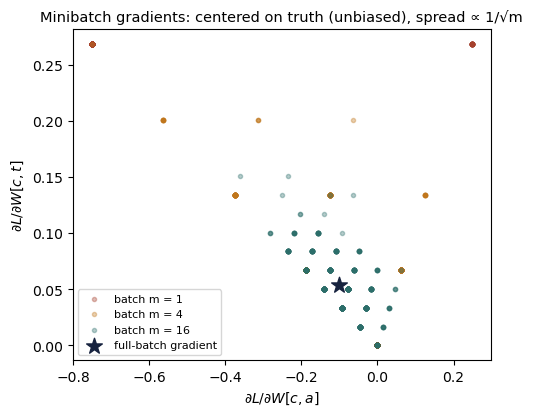

mean of 500 single-example gradients: -0.1118    full-batch value: -0.1003   (they agree: unbiased)


In [30]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL, RED = "#17233F", "#C0761B", "#2C6E6A", "#A6412E"

# a learnable bigram model: logits for the next char given the previous char are row W[prev].
pairs = np.array([[stoi[a], stoi[b]] for a, b in zip(corpus, corpus[1:])])   # corpus from Chapter 0
N = len(pairs)
rng5 = np.random.default_rng(1)
W_fixed = rng5.normal(size=(V, V)) * 0.3

def batch_grad(batch, W):
    G = np.zeros((V, V))
    for prev, nxt in batch:
        p = softmax(W[prev]).copy(); p[nxt] -= 1        # dL/dz = p - onehot, from Chapter 1
        G[prev] += p
    return G / len(batch)

full_grad = batch_grad(pairs, W_fixed)                  # the true gradient over all N positions

def sample(m, reps=500):
    return np.array([batch_grad(pairs[rng5.integers(0, N, m)], W_fixed) for _ in range(reps)])

# watch two coordinates of the gradient: the 'c'->'a' entry and the 'c'->'t' entry
r = stoi['c']; ca, ct = stoi['a'], stoi['t']
fig, ax = plt.subplots(figsize=(5.4, 4.3))
for m, col in [(1, RED), (4, AMBER), (16, TEAL)]:
    S = sample(m)
    ax.scatter(S[:, r, ca], S[:, r, ct], s=9, alpha=0.35, color=col, label=f"batch m = {m}")
ax.scatter([full_grad[r, ca]], [full_grad[r, ct]], color=INK, marker="*", s=140, zorder=6,
           label="full-batch gradient")
ax.set_xlabel(r"$\partial L / \partial W[c,a]$"); ax.set_ylabel(r"$\partial L / \partial W[c,t]$")
ax.set_title("Minibatch gradients: centered on truth (unbiased), spread ∝ 1/√m", fontsize=10.5)
ax.legend(fontsize=8); plt.show()

print("mean of 500 single-example gradients:", round(sample(1).mean(0)[r, ca], 4),
      "   full-batch value:", round(full_grad[r, ca], 4), "  (they agree: unbiased)")

Every cloud is centered on the star — unbiasedness, made visible — and the clouds tighten as $m$ grows. This is the entire statistical justification for stochastic gradient descent: it walks in the correct direction on average, and the batch size is a dial on how jittery the walk is. In the flow language of Chapter 5, SGD is a *noisy* Euler discretization of the gradient flow $\dot\theta = -\nabla\widehat R$.

### Why the optimizer is adaptive

Plain SGD uses one global step size, which is a problem when the loss is **ill-conditioned** — steep in some directions, nearly flat in others. The step must stay small enough not to diverge along the steep direction, which leaves it crawling along the flat ones. AdamW fixes this by keeping a running estimate of each coordinate's gradient magnitude and *rescaling per coordinate* (plus decoupled weight decay, a clean $\ell_2$ pull applied separately from the gradient step). Race them on a deliberately stiff quadratic.

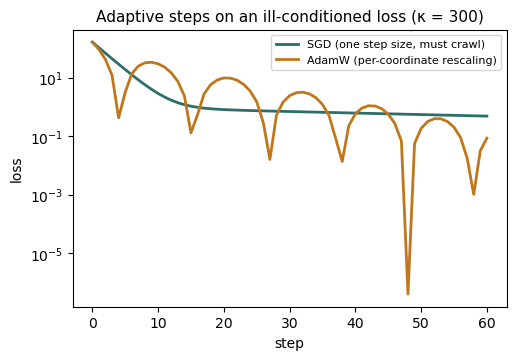

In [31]:
import numpy as np
import matplotlib.pyplot as plt
AMBER, TEAL = "#C0761B", "#2C6E6A"

kappa = np.array([1.0, 1.0, 30.0, 300.0])            # curvatures: condition number 300
loss = lambda w: 0.5 * np.sum(kappa * w * w)
grad = lambda w: kappa * w

def run_sgd(lr, steps=60):
    w = np.ones(4); h = [loss(w)]
    for _ in range(steps): w = w - lr * grad(w); h.append(loss(w))
    return h

def run_adamw(lr, steps=60, b1=0.9, b2=0.999, eps=1e-8, wd=0.0):
    w = np.ones(4); m = v = np.zeros(4); h = [loss(w)]
    for t in range(1, steps + 1):
        g = grad(w)
        m = b1 * m + (1 - b1) * g;      v = b2 * v + (1 - b2) * g * g
        mhat = m / (1 - b1**t);         vhat = v / (1 - b2**t)
        w = w - lr * mhat / (np.sqrt(vhat) + eps) - lr * wd * w
        h.append(loss(w))
    return h

sgd  = run_sgd(lr=0.9 * 2 / kappa.max())             # near the stability limit set by the stiff direction
adam = run_adamw(lr=0.25)
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.semilogy(sgd,  color=TEAL,  lw=2, label="SGD (one step size, must crawl)")
ax.semilogy(adam, color=AMBER, lw=2, label="AdamW (per-coordinate rescaling)")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(fontsize=8)
ax.set_title("Adaptive steps on an ill-conditioned loss (κ = 300)", fontsize=11); plt.show()

**The AdamW update, stated precisely.** At step $k$, with gradient $g_k$ and defaults $\beta_1,\beta_2,\eta,\lambda,\varepsilon$:

$$
m_k=\beta_1 m_{k-1}+(1-\beta_1)g_k,\quad v_k=\beta_2 v_{k-1}+(1-\beta_2)g_k^2,\quad \hat m_k=\tfrac{m_k}{1-\beta_1^k},\ \hat v_k=\tfrac{v_k}{1-\beta_2^k},
$$
$$
\theta_{k+1}=\theta_k-\eta\Big(\tfrac{\hat m_k}{\sqrt{\hat v_k}+\varepsilon}+\lambda\,\theta_k\Big).
$$

Two features matter. First, the $1/\sqrt{\hat v_k}$ denominator adapts each coordinate to its recent RMS gradient scale; it does **not** make every update exactly $\pm\eta$. At the first step, bias correction gives $\hat m_1=g_1$ and $\hat v_1=g_1^2$, so the adaptive component is exactly $\eta g_1/(|g_1|+\varepsilon)$ and is approximately $\pm\eta$ only when $g_1\ne0$ and $|g_1|\gg\varepsilon$. Thus $g_1=0.5$ and $500$ produce nearly the same adaptive magnitude when $\varepsilon=10^{-8}$, while gradients comparable to or smaller than $\varepsilon$ do not. Second, the decay $\lambda\theta_k$ is applied **decoupled** from the preconditioner — that decoupling is the "W" in AdamW. The bias corrections fix the cold start $m_0=v_0=0$; they do not remove the epsilon or decay terms.

### The payoff: generalization early, memorization late

Return to the very first break in this course. In Chapter 0 the count table assigned $p(t\mid c)=0$ — infinite loss — declaring a legal string impossible, because `ct` never appeared. Watch what a *learned* model does instead, over the course of training. Factor the bigram logits through a small shared embedding, $\text{logit}(j\mid i)=E_i\cdot U_j$, train it by gradient descent, and record $p(t\mid c)$ at every step. The number's *trajectory* is the whole story of learning.

step    1:  p(t | 'c') = 0.2406
step   10:  p(t | 'c') = 0.1224
step  100:  p(t | 'c') = 0.0018
step 1499:  p(t | 'c') = 0.0001

count table (Chapter 0):  p(t | 'c') = 0.0000   -- the memorization floor


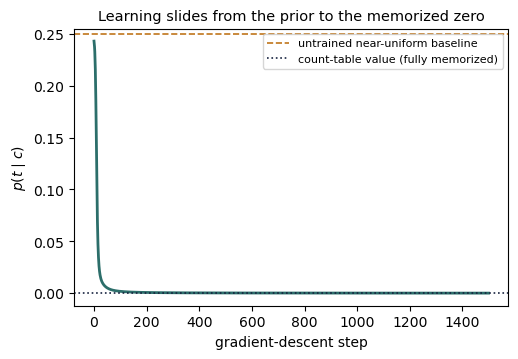

In [32]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL = "#17233F", "#C0761B", "#2C6E6A"

def train_ptc(k=2, steps=1500, lr=1.0, seed=0):
    r = np.random.default_rng(seed)
    E = r.normal(size=(V, k)) * 0.5; U = r.normal(size=(V, k)) * 0.5
    ptc = []                                          # p(t | 'c') recorded each step
    for _ in range(steps):
        gE = np.zeros_like(E); gU = np.zeros_like(U)
        for prev, nxt in pairs:
            p = softmax(E[prev] @ U.T).copy(); p[nxt] -= 1     # p - onehot, from Chapter 1
            gE[prev] += p @ U; gU += np.outer(p, E[prev])
        E -= lr * gE / N; U -= lr * gU / N
        ptc.append(softmax(E[stoi['c']] @ U.T)[stoi['t']])
    return np.array(ptc)

ptc = train_ptc(k=2)
for s in [1, 10, 100, 1499]:
    print(f"step {s:>4}:  p(t | 'c') = {ptc[s]:.4f}")
print(f"\ncount table (Chapter 0):  p(t | 'c') = 0.0000   -- the memorization floor")

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(ptc, color=TEAL, lw=2)
ax.axhline(1/V, color=AMBER, lw=1.2, ls="--", label="untrained near-uniform baseline")
ax.axhline(0.0, color=INK, lw=1.2, ls=":", label="count-table value (fully memorized)")
ax.set_xlabel("gradient-descent step"); ax.set_ylabel(r"$p(t \mid c)$")
ax.legend(fontsize=8); ax.set_title("Learning slides from the prior to the memorized zero", fontsize=10.5)
plt.show()

The trajectory is the lesson, and it reads in two halves. The model *starts* near the uniform prior: from small random weights $E_i\cdot U_j\approx 0$ for **every** pair, so `ct` — and every other pair, sensible or not — gets near-equal probability. That is **ignorance, not transfer**: no structure has been learned yet, and near-uniform *output* alone cannot support the claim "the model generalizes." What nonzero softmax support does buy, immediately and for free, is escape from the count table's infinite loss.

As training proceeds, $p(t\mid c)$ slides toward zero: the model squeezes toward the corpus's accidental gap, and the slide is the *shape* of **overfitting** — properly defined as a divergence between training and held-out behavior, not merely convergence toward an empirical conditional. (For *this* rank-2 factorized model the unregularized MLE approaches the empirical conditional — the count table — only insofar as that conditional is representable by the factorization and optimization reaches it: a caveat, not a law. A tighter bottleneck — smaller embedding rank, or weight decay — slows the slide by giving the model less freedom to memorize.) Genuine generalization is a claim about *held-out* behavior, and it must be demonstrated by an improved held-out metric. The next section does exactly that.

### Generalization is a held-out claim — so hold data out

The slide above showed *training* behavior; "the model generalizes" is only demonstrated on data the model was not fit to. Draw a train and a disjoint validation stream from a fixed true bigram process, train on a *small* train set, and watch **both** losses. Early, validation NLL falls with training NLL — the model is learning real structure that transfers (generalization). Past a point, training NLL keeps falling toward the small sample's *empirical* conditional while validation NLL turns back up: the model is now memorizing sampling noise the held-out set does not share. That turning point — a validation minimum that occurs *before* the end of training — is the operational signature of overfitting, and why we stop on a validation signal.

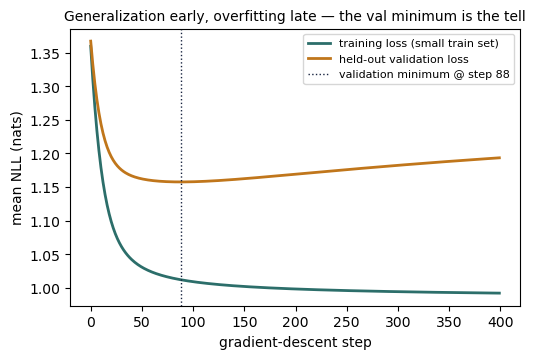

validation NLL: start 1.367  ->  min 1.158 @ step 88  ->  end 1.194
training   NLL: start 1.359  ->  end 0.992  (keeps falling: memorizing the sample)
Generalization is early; overfitting is late — demonstrated on held-out data, not asserted.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL = "#17233F", "#C0761B", "#2C6E6A"

# a fixed TRUE bigram process with real structure and no structural zeros (finite held-out loss)
base = np.array([[2, 1, .3, .15], [.15, .3, 2, 1], [1, 2, .15, .3], [.3, .15, 1, 2]], float)
trueT = base / base.sum(1, keepdims=True)
def sample_pairs(n, seed):
    r = np.random.default_rng(seed); s = 0; out = []
    for _ in range(n):
        nxt = int(r.choice(V, p=trueT[s])); out.append((s, nxt)); s = nxt
    return np.array(out)
def mean_nll(W, batch):
    return float(np.mean([-np.log(softmax(W[p])[n] + 1e-12) for p, n in batch]))

train_small = sample_pairs(40, 1)          # small enough to memorize its sampling noise
val_large   = sample_pairs(600, 2)         # disjoint, from the same true process
W = np.zeros((V, V)); tr_hist, va_hist = [], []
for step in range(400):
    G = np.zeros((V, V))
    for p, n in train_small:
        q = softmax(W[p]).copy(); q[n] -= 1; G[p] += q
    W -= 0.5 * G / len(train_small)
    tr_hist.append(mean_nll(W, train_small)); va_hist.append(mean_nll(W, val_large))

va = np.array(va_hist); vmin = int(va.argmin())
fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(tr_hist, color=TEAL, lw=2, label="training loss (small train set)")
ax.plot(va_hist, color=AMBER, lw=2, label="held-out validation loss")
ax.axvline(vmin, color=INK, lw=1, ls=":", label=f"validation minimum @ step {vmin}")
ax.set_xlabel("gradient-descent step"); ax.set_ylabel("mean NLL (nats)")
ax.legend(fontsize=8); ax.set_title("Generalization early, overfitting late — the val minimum is the tell", fontsize=10)
plt.show()

# the lesson, asserted against the actual run:
assert 0 < vmin < len(va) - 1                 # the dip happens, and is not the last step
assert va[vmin] < va[0]                        # validation genuinely IMPROVED (generalization)
assert va[-1] > va[vmin]                        # then WORSENED past the minimum (overfitting)
print(f"validation NLL: start {va[0]:.3f}  ->  min {va[vmin]:.3f} @ step {vmin}  ->  end {va[-1]:.3f}")
print(f"training   NLL: start {tr_hist[0]:.3f}  ->  end {tr_hist[-1]:.3f}  (keeps falling: memorizing the sample)")
print("Generalization is early; overfitting is late — demonstrated on held-out data, not asserted.")

**Self-checks (Ch 6).** (a) A minibatch gradient is *unbiased* — state precisely what that does and does not promise about a single step. (b) What does overfitting look like on the train/validation curves above, and why is the validation *minimum* (not its final value) the stopping signal? (c) In the AdamW update, start from $m_0=v_0=0$ and show that bias correction recovers $\hat m_1=g_1$ and $\hat v_1=g_1^2$ exactly. Hence the first-step adaptive component is $\eta\,g_1/(|g_1|+\varepsilon)$. State the condition $g_1\ne0$ and $|g_1|\gg\varepsilon$ under which this is approximately $\pm\eta$; then explain what happens when $|g_1|\lesssim\varepsilon$ or $g_1=0$, and how the decoupled decay $\lambda\theta$ changes the full parameter update.

**Where we stand.** The *training discipline* is in hand — unbiased minibatch steps, per-coordinate adaptive scaling, and a held-out protocol that can tell learning from memorizing — exercised here on the factorized bigram; the assembled transformer has, so far, trained one tied parameter group through its full stack.

**The forced move.** We now have a *fitted* model — it assigns calibrated-looking distributions to prefixes. But a distribution is not text. Turning $p_\theta(\cdot\mid x_{<t})$ into an actual sequence is a separate layer of decisions, and it is where every sampling knob you have ever touched in an API call lives. That is the next chapter.

## 7 · Generation: the knobs are the policy

The trained bigram used below defines, for every prefix, a distribution over the next token — and that is *all* it defines. The assembled transformer above was only partially optimized, as its section states. It does not define text. Turning $p_\theta(\cdot\mid x_{<t})$ into an actual sequence is a separate layer of decisions made at inference time, and the parameters never move while you make them. Every sampling field you have ever set in an API call — `temperature`, `top_k`, `top_p` — lives in this layer. This chapter is those fields, each with an exact mathematical identity.

The obvious way to generate is to always take the most likely token. Build it and watch it fail.

### The break: greedy decoding collapses

Train a next-character model, then generate by taking the argmax at every step. Compare against drawing from the distribution.

In [34]:
import numpy as np
np.set_printoptions(suppress=True)

# train a bigram next-char model p(next | prev) by gradient descent (pairs, N from Chapter 6)
Wg = np.zeros((V, V))
for _ in range(600):
    G = np.zeros((V, V))
    for prev, nxt in pairs:
        p = softmax(Wg[prev]).copy(); p[nxt] -= 1        # p - onehot
        G[prev] += p
    Wg -= 1.0 * G / N

def generate(start, n, temp=1.0, greedy=False, seed=0):
    r = np.random.default_rng(seed)
    prev = stoi[start]; out = [start]
    for _ in range(n):
        p = softmax(Wg[prev] / temp)
        nxt = int(p.argmax()) if greedy else int(r.choice(V, p=p))
        out.append(VOCAB[nxt]); prev = nxt
    return "".join(out)

print("greedy (argmax every step):")
print("   '" + generate(' ', 26, greedy=True) + "'   <- locked in a cycle")
print("\nsampling (draw from the distribution):")
for s in range(3):
    print("   '" + generate(' ', 26, temp=1.0, seed=s) + "'")

greedy (argmax every step):
   ' cat cat cat cat cat cat ca'   <- locked in a cycle

sampling (draw from the distribution):
   ' t a tatatat t t t ca atat '
   ' ca t caca t caca c cacatat'
   ' cat cac cat cacatac cataca'


Greedy decoding is deterministic, so on a model whose entire state is the previous character it must repeat forever the moment it revisits a state — the state space here has only four elements, so a cycle is quickly forced. Be careful generalizing the *mechanism*: a transformer decoder's effective state is the whole retained prefix (its KV state), not a single token, so appending a repeated token does **not** revisit the same state, and the exact finite-state cycle argument does not transfer. The empirical fact still holds — large models decoded greedily tend to lose diversity and can fall into repetition — but that depends on the learned conditional distribution and the context window, not on this toy's four-state determinism. Sampling breaks the determinism; raw sampling can wander into low-probability nonsense, so in practice we reshape the distribution first. That reshaping is the policy layer, and it is three moves on the same object.

### The repair: three ways to reshape the simplex

Everything below acts on the frozen conditional $p=\sigma(z)$ and nothing else — the model is untouched.

- **Temperature** is exactly the Chapter-1 dial: sample from $\sigma(z/T)$. As $T\to 0$ the distribution sharpens to the argmax (so *greedy is temperature zero*); as $T\to\infty$ it flattens to uniform. Low $T$ is conservative, high $T$ is adventurous.
- **top-$k$** keeps the $k$ highest-probability tokens and renormalizes — a hard truncation of the simplex to its top corner.
- **top-$p$** (nucleus) keeps the *smallest* set of tokens whose cumulative probability reaches $p$, then renormalizes — an adaptive truncation that keeps few tokens when the model is confident and many when it is unsure.

Implement all three on one fixed logit vector and watch each reshape it.

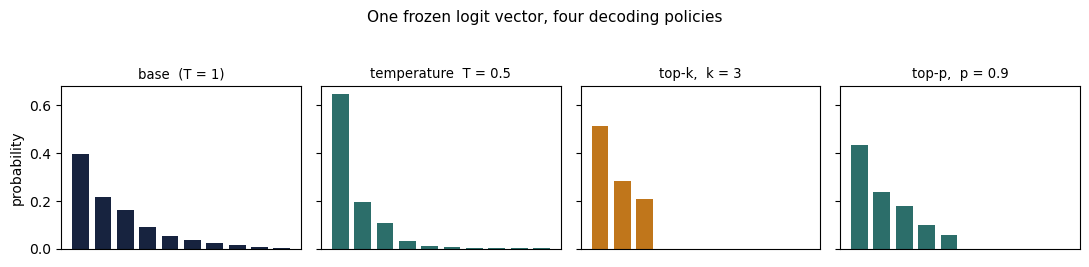

greedy  ==  temperature→0  ==  top-1 : True
top-p (p=0.9) keeps the 5 most probable tokens covering 90% of the mass


In [35]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL = "#17233F", "#C0761B", "#2C6E6A"

z = np.array([3.0, 2.4, 2.1, 1.5, 1.0, 0.6, 0.2, -0.4, -1.0, -1.6])   # a fixed 10-token logit vector

temperature = lambda z, T: softmax(z / T)
def top_k(p, k):
    q = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; q[idx] = p[idx]; return q / q.sum()
def top_p(p, thr):
    order = np.argsort(p)[::-1]; cut = np.searchsorted(np.cumsum(p[order]), thr) + 1
    q = np.zeros_like(p); q[order[:cut]] = p[order[:cut]]; return q / q.sum()

base = softmax(z)
panels = [("base  (T = 1)", base, INK), ("temperature  T = 0.5", temperature(z, 0.5), TEAL),
          ("top-k,  k = 3", top_k(base, 3), AMBER), ("top-p,  p = 0.9", top_p(base, 0.9), TEAL)]
fig, axes = plt.subplots(1, 4, figsize=(11, 2.5), sharey=True)
for ax, (title, p, col) in zip(axes, panels):
    ax.bar(range(len(z)), p, color=col, width=0.75); ax.set_title(title, fontsize=9.5); ax.set_xticks([])
axes[0].set_ylabel("probability")
fig.suptitle("One frozen logit vector, four decoding policies", y=1.05, fontsize=11)
plt.tight_layout(); plt.show()

print("greedy  ==  temperature→0  ==  top-1 :",
      np.allclose(top_k(base, 1), np.eye(len(z))[base.argmax()]))
print(f"top-p (p=0.9) keeps the {(top_p(base, 0.9) > 0).sum()} most probable tokens covering 90% of the mass")

Three knobs, one simplex, all of them inference-time reshapings that leave the trained model exactly as it was. That immediately raises a question they cannot answer: if a good sample can come from luck and a bad one from an unlucky draw, how do we *measure* whether the model is any good?

### Evaluation: judge the model, not the sample

A single generated string is noisy evidence — it may read fluently or break by chance. The honest, aggregate measure is **perplexity** on held-out text: $\exp$ of the average negative log-likelihood the model assigns to *real* continuations. It is the geometric-mean uncertainty — "as unsure as a fair choice among this many tokens" — and, crucially, it scores the model against data, independent of any decoding choice.

### One more decoder, a different kind of object: beam search

Temperature, top-$k$, and top-$p$ all reshape *one step's* next-token distribution and then sample a token. **Beam search** is not that — it is a search over whole sequences. It keeps the $K$ highest-scoring partial sequences ("beams") at each step, scored by accumulated log-probability

$$
\log p(y_{1:i}\mid x)=\log p(y_{<i}\mid x)+\log p(y_i\mid x,y_{<i}),
$$

and expands them together, so it can escape a locally attractive but globally poor token that greedy would lock into. The trade-offs: it is (near-)deterministic and tends toward bland, high-probability text, and it costs about $K\times$ the compute. Keep the distinction sharp — top-$k$/top-$p$ **condition and sample** from a single step's simplex; beam search **plans over sequences**. (This is why the library `model.generate(...)` lists `beam` alongside the sampling knobs: same API, different kind of algorithm.)

In [36]:
def perplexity(text):
    ids = [stoi[c] for c in text]; nll = 0.0
    for prev, nxt in zip(ids, ids[1:]):
        nll += -np.log(softmax(Wg[prev])[nxt])
    return np.exp(nll / (len(ids) - 1))

print(f"perplexity on the training corpus  : {perplexity(corpus):.3f}")
print(f"perplexity on held-out 'a tac cat'  : {perplexity('a tac cat'):.3f}")
print("\nPerplexity grades the model against real text; it does not depend on the")
print("sampling temperature. Temperature shapes what the model GENERATES; perplexity")
print("measures what the model BELIEVES. A cherry-picked sample can flatter a model")
print("that a held-out perplexity would expose.")

perplexity on the training corpus  : 2.349
perplexity on held-out 'a tac cat'  : 2.739

Perplexity grades the model against real text; it does not depend on the
sampling temperature. Temperature shapes what the model GENERATES; perplexity
measures what the model BELIEVES. A cherry-picked sample can flatter a model
that a held-out perplexity would expose.


### Two inference regimes, and why the KV cache is free

One implementation fact shapes all serving economics. Generating a token needs attention over the whole prefix, and the keys and values of earlier positions do not change as new tokens arrive. So a production model runs in two phases: **prefill** processes the prompt in parallel and stores every position's key and value once; **decode** then generates one token at a time, computing only the *new* position's key and value and reading the stored rest. The cache is a pure optimization — it changes speed, never the result. Prove both halves.

cached output == full recompute : True (the cache is exact)



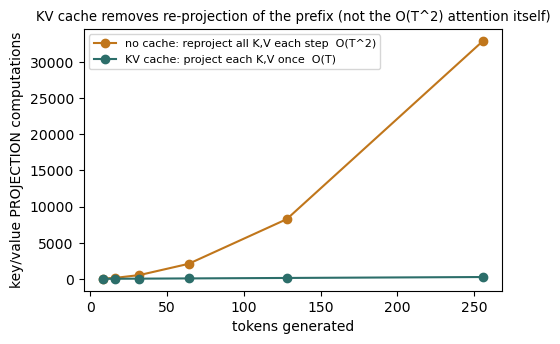

at 256 tokens: 32,896 vs 256 key/value projections — 128x fewer


In [37]:
import numpy as np
import matplotlib.pyplot as plt
AMBER, TEAL = "#C0761B", "#2C6E6A"

rng7 = np.random.default_rng(5); D = 4; Tfull = 6
Xseq = rng7.normal(size=(Tfull, D))
Wq, Wk, Wv = (rng7.normal(size=(D, D)) for _ in range(3))

# (a) recompute the last position's attention output from scratch
def attn_last_full(X):
    Q, K, Vv = X @ Wq, X @ Wk, X @ Wv
    return softmax((Q[-1] @ K.T) / np.sqrt(D)) @ Vv

# (b) cached: keys/values built incrementally, each computed once and reused
Kc = [x @ Wk for x in Xseq]; Vc = [x @ Wv for x in Xseq]
q_new = Xseq[-1] @ Wq
out_cached = softmax((q_new @ np.array(Kc).T) / np.sqrt(D)) @ np.array(Vc)
print("cached output == full recompute :", np.allclose(out_cached, attn_last_full(Xseq)), "(the cache is exact)\n")

# What the cache actually saves is RECOMPUTING prior keys/values. Count K/V PROJECTIONS:
#   no cache: reprojects all t positions each step  -> sum_t t = O(T^2) projection ops
#   cache:    projects each position's K,V once     -> O(T) projection ops
# NOTE: this is NOT total decode complexity. Even with the cache, each new query still
# attends over a cache of length t, so dense attention work is sum_t O(t) = O(T^2) overall.
Ts = np.array([8, 16, 32, 64, 128, 256]); naive = Ts * (Ts + 1) // 2; cached = Ts
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot(Ts, naive, "o-", color=AMBER, label="no cache: reproject all K,V each step  O(T^2)")
ax.plot(Ts, cached, "o-", color=TEAL, label="KV cache: project each K,V once  O(T)")
ax.set_xlabel("tokens generated"); ax.set_ylabel("key/value PROJECTION computations"); ax.legend(fontsize=8)
ax.set_title("KV cache removes re-projection of the prefix (not the O(T^2) attention itself)", fontsize=9.5)
plt.show()
print(f"at 256 tokens: {naive[-1]:,} vs {cached[-1]:,} key/value projections — {naive[-1]//cached[-1]}x fewer")

That gap is why the KV cache is universal: it turns $O(T^2)$ **re-projection of the prefix's keys and values** into $O(T)$ by computing each position's key/value once and reusing it. Be precise about what it does *not* buy — it is not an $O(T)$ decode. Each newly generated query still attends over a cache whose length grows with $t$, so the dense-attention work over a full generation is still $\sum_{t=1}^{T}O(t)=O(T^2)$ at fixed width. The cache changes speed by removing recomputation, never the result; the *size* it stores — one key/value per layer per head per cached position — is what quantization (Chapter 10) later fights to shrink.

**Where we stand.** A trained model speaks — the bigram, here — and its beliefs (the conditionals) are a separate layer from its voice (the decoding policy); serving splits cleanly into prefill and decode.

**The forced move.** We can now train a model and decode from it, but everything it produces is *generic* continuation — it imitates its pretraining text. We want a model that follows instructions. Remarkably, that needs no new objective at all, only a change in what we train on and which tokens we score. That is the next chapter.

## 8 · Fine-tuning: same loss, different measure

A pretrained model predicts generic text. An instruction-follower answers questions. The gap between them sounds like it should require a new kind of learning — reinforcement, a reward, something. It does not. Supervised fine-tuning uses the *identical* next-token cross-entropy from Chapter 1. Only two things change: **what** we train on (curated instruction–response pairs instead of raw text) and **which tokens** the loss is allowed to score. The second change is the subtle one, and getting it wrong quietly wastes the model's capacity.

Format an example as a prompt followed by a response:

```
### Instruction:   <the user's task>
### Response:      <the desired answer>
```

The naive move is to run ordinary cross-entropy over the whole sequence. Watch what that spends its effort on.

### The break, and the one-line repair

Ordinary cross-entropy averages the loss over *every* position — including the prompt tokens. But training the model to predict the prompt teaches it to *generate the user's instructions*, which is not the job; we want it to **condition** on the instruction and be graded only on the **response**. The fix is a loss **mask**: a vector $m\in\{0,1\}$ that is $0$ on prompt positions and $1$ on response positions. The masked risk

$$
L_m(\theta) = \frac{\sum_{b,t} m_{b,t}\,\big[-\log p_\theta(y_{b,t}\mid x_{b,1:t})\big]}{\sum_{b,t} m_{b,t}}
$$

is just the per-token loss averaged under a *reweighted* measure that puts all its mass on response positions. Ordinary cross-entropy is the special case $m\equiv 1$. The model class, the pointwise loss, and the optimizer are all untouched — masking changes only the measure in the average. Make the arithmetic transparent with fixed per-token losses.

ordinary cross-entropy (all tokens) : 1.475
   -> 75% of that loss is spent predicting the PROMPT
      (i.e. teaching the model to generate the user's instruction — not the goal)

masked risk (response tokens only)  : 0.750
   -> every SUPERVISED TARGET is now a response token
   -> prompt positions get loss weight 0, so their DIRECT loss term is 0 (response gradients still flow through them via attention)


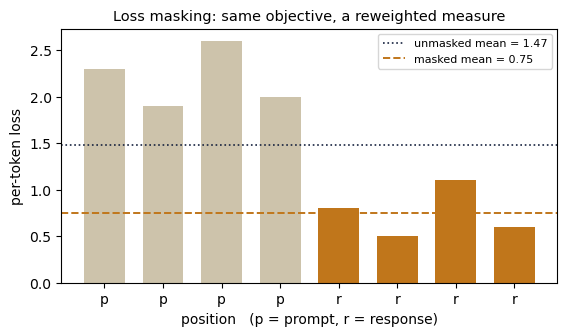

In [38]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, RULE = "#17233F", "#C0761B", "#CDC3AB"

# a formatted example: four prompt positions, then four response positions.
# per-token losses are illustrative, so the masking arithmetic is fully visible.
per_token_loss = np.array([2.3, 1.9, 2.6, 2.0, 0.8, 0.5, 1.1, 0.6])
is_response    = np.array([0,   0,   0,   0,   1,   1,   1,   1  ])   # mask: prompt=0, response=1

unmasked     = per_token_loss.mean()
masked       = (is_response * per_token_loss).sum() / is_response.sum()
prompt_share = per_token_loss[is_response == 0].sum() / per_token_loss.sum()

print(f"ordinary cross-entropy (all tokens) : {unmasked:.3f}")
print(f"   -> {prompt_share*100:.0f}% of that loss is spent predicting the PROMPT")
print(f"      (i.e. teaching the model to generate the user's instruction — not the goal)\n")
print(f"masked risk (response tokens only)  : {masked:.3f}")
print(f"   -> every SUPERVISED TARGET is now a response token")
print(f"   -> prompt positions get loss weight 0, so their DIRECT loss term is 0 (response gradients still flow through them via attention)")

fig, ax = plt.subplots(figsize=(6.4, 3.3))
ax.bar(range(len(per_token_loss)), per_token_loss,
       color=[RULE if r == 0 else AMBER for r in is_response], width=0.7)
ax.axhline(unmasked, color=INK,   ls=":",  lw=1.2, label=f"unmasked mean = {unmasked:.2f}")
ax.axhline(masked,   color=AMBER, ls="--", lw=1.4, label=f"masked mean = {masked:.2f}")
ax.set_xticks(range(len(per_token_loss))); ax.set_xticklabels(list("pppp") + list("rrrr"))
ax.set_xlabel("position   (p = prompt, r = response)"); ax.set_ylabel("per-token loss")
ax.legend(fontsize=8); ax.set_title("Loss masking: same objective, a reweighted measure", fontsize=10.5)
plt.show()

The prompt tokens still sit in the context — the model reads them, attends to them, conditions on them — so setting their loss weight to zero removes their **direct loss terms**, not all learning that touches them. Be precise: because every response logit depends on attention over the prompt's values $v_s=X_sW_V$, gradients from the *response* targets still backpropagate through the prompt embeddings and the prompt's keys/values ($\partial L_{\text{response}}/\partial X_s$ is generally nonzero even where the prompt's own mask entry is $0$), and shared parameters can shift prompt-like tokens elsewhere too. What masking guarantees is narrower and exactly what we want: **all supervised targets are response tokens**, so the model is never trained to *emit* the instruction, while it is fully trained to condition on it.

Everything that makes this "fine-tuning" rather than "pretraining" is captured by two swaps: the data distribution (curated pairs) and the empirical measure (the mask). The pointwise cross-entropy, the softmax head, the gradient $p-e_y$, the optimizer — all identical. This is the whole two-stage recipe in miniature: pretrain on broad text to learn language, then fine-tune on a narrow, formatted distribution to shape behavior, using the same machinery both times.

**Where we stand.** The instruction-following recipe is on the table — same loss, same gradient, a reweighted measure — demonstrated here in masking arithmetic; no instruction model is trained in this course.

**The forced move.** Masked token likelihood can learn from good responses and generalize beyond the exact answers shown. What it does **not directly consume** is a comparative label such as *"answer A is better than answer B."* When relative judgments are easier or more informative than writing a target response, pairwise preferences provide a distinct supervision signal. Using that signal requires one more idea — and with it, the structure you have now met twice returns. That derivation is Chapter 11; but two practical layers sit between here and any deployed system that could run it, and the course clears them first: the objects need their production names (Chapter 9), and the model must be small enough to serve (Chapter 10).

## 9 · Translation: your objects become library abstractions

This is a dictionary, not a movement — deliberately short, because there is no new idea here, only new names. Everything built from raw arrays in Chapters 0–8 has a close counterpart in PyTorch and Hugging Face (conceptual analogues, not always exact drop-ins). Knowing the map means you can read production code as *the same mathematics with production ergonomics*: batching, automatic differentiation, and fused GPU kernels wrapped around objects you have already built by hand.

| From-scratch object (this course) | Library abstraction | What the library adds |
| --- | --- | --- |
| `W_E[ids]` embedding lookup (Ch 3) | `torch.nn.Embedding` | gradient tracking, device placement |
| `attention(...)` (Ch 4) | `nn.MultiheadAttention`, `GPT2Attention` | fused kernels, dropout, batched heads |
| the pre-norm block (Ch 5) | `GPT2Block` (decoder-only match); *cf.* `nn.TransformerDecoderLayer`, which additionally has encoder **cross-attention** and is not a drop-in | tested init, config plumbing |
| SGD / AdamW by hand (Ch 6) | `torch.optim.AdamW` | fused updates, schedulers, param groups |
| `-log p[y]` cross-entropy (Ch 1) | `F.cross_entropy` | batching, numerical care, class weights |
| `generate(...)` decode loop (Ch 7) | `model.generate(...)` | KV cache, top-k/top-p/beam, stopping |
| the loss mask (Ch 8) | `labels` with `-100` ignore index | vectorized masked reduction |
| tokenizer + `get_batch` | `tokenizers`, `datasets`, `DataLoader` | streaming, collation, sharding |

The one thing worth verifying is that "batched, framework-style" cross-entropy is numerically equal (to floating-point tolerance) to the loss you already wrote — the library just removes the Python loop.

### Transformer families are not drop-ins

| Family | Attention contract | Typical objective / use |
| --- | --- | --- |
| **Encoder-only** | bidirectional self-attention over the input | masked-token or representation learning; classification, retrieval, tagging |
| **Decoder-only** | causal self-attention over the prefix | next-token prediction; completion and chat |
| **Encoder-decoder** | encoder self-attention plus decoder causal self-attention and cross-attention | teacher-forced conditional generation; translation and summarization |

This notebook builds the decoder-only case. A BERT-style encoder is not a drop-in autoregressive generator, and PyTorch's `TransformerDecoderLayer` implements the encoder-decoder boundary by accepting encoder `memory`; that is why `GPT2Block` is the closer analogue above.


In [39]:
import numpy as np

# from-scratch: average negative log-likelihood over a batch of positions, one at a time
def ce_from_scratch(logits, targets):
    total = 0.0
    for z, y in zip(logits, targets):
        total += -np.log(softmax(z)[y])
    return total / len(targets)

# library-style: the identical computation, fully vectorized (no Python loop over the batch)
def ce_vectorized(logits, targets):
    Z = logits - logits.max(axis=1, keepdims=True)   # max-shift once; the shift cancels in -Z_y + logsumexp(Z)
    logsumexp = np.log(np.exp(Z).sum(1))              # stable: every exponent is <= 0 after the shift
    return (-(Z[np.arange(len(targets)), targets]) + logsumexp).mean()

rng9 = np.random.default_rng(0)
logits = rng9.normal(size=(8, 5)); targets = rng9.integers(0, 5, size=8)
print("from-scratch cross-entropy :", round(ce_from_scratch(logits, targets), 6))
print("vectorized  cross-entropy :", round(ce_vectorized(logits, targets), 6))
print("equal within fp tolerance:", np.allclose(ce_from_scratch(logits, targets), ce_vectorized(logits, targets)))
# NOTE: both are numpy here (this env has no torch); we show numerical equivalence, not a byte-identical
# match to a framework F.cross_entropy. Reduction order can differ in the low bits while the math agrees.

from-scratch cross-entropy : 1.868627
vectorized  cross-entropy : 1.868627
equal within fp tolerance: True


Same number. The framework is not a different theory — it is this course's objects with the loops pushed down into C and CUDA.

**Where we stand.** Every part of the machine now has its production name — and nothing in the library is new theory.

**The forced move.** We have a model, a way to train it, decode from it, and now name its parts in a real stack. What we have not addressed is **direct supervision from pairwise preference labels**. Token likelihood can generalize beyond its demonstrations, but it does not take *A is preferred to B* as an input to the loss. Two practical layers still sit between here and a deployed system: making the model small enough to serve (next), and training directly from comparative judgments (the chapter after). Both are next.

## 10 · Quantization: the weights live on a finite grid

Every weight so far has been a full-precision float. A deployed model has hundreds of billions of them, and both storage and the memory bandwidth of inference are dominated by moving those numbers around. The obvious economy is to store each weight in fewer bits — round it to one of a small number of grid points. The obvious risk is that rounding destroys information. This chapter is exactly that tradeoff: what breaks when you round, how to round well, and how much accuracy a given number of bits costs.

Start with the break. Round a weight vector to a 3-bit grid — only $2^3 = 8$ distinct values — and look at the damage.

8-bit (256 levels):  mean |error| = 0.0053   max |error| = 0.0108
4-bit ( 16 levels):  mean |error| = 0.0914   max |error| = 0.1844
3-bit (  8 levels):  mean |error| = 0.1944   max |error| = 0.3950
2-bit (  4 levels):  mean |error| = 0.4515   max |error| = 0.9207


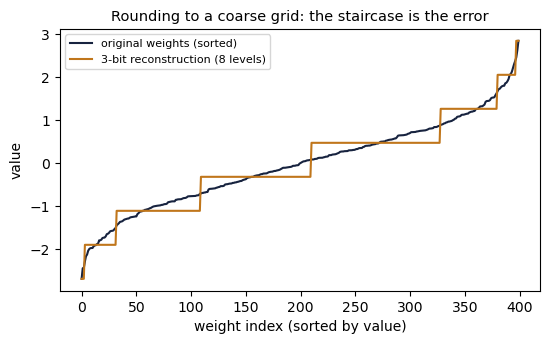


bigram perplexity: full 2.349   3-bit 2.391   1-bit 2.503


In [40]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL, RULE = "#17233F", "#C0761B", "#2C6E6A", "#CDC3AB"

def quantize(x, bits, per_channel=False, axis=-1):
    # min/max fake quantization: one affine grid, without forcing an integer zero-point
    qmax = 2**bits - 1
    if per_channel:
        lo = x.min(axis, keepdims=True); hi = x.max(axis, keepdims=True)
    else:
        lo = x.min(); hi = x.max()
    scale = np.where((hi - lo) == 0, 1.0, (hi - lo) / qmax)
    q = np.round((x - lo) / scale)               # nearest grid index
    return q * scale + lo                         # dequantized approximation

rng8 = np.random.default_rng(2)
w = rng8.normal(size=400)                         # a full-precision weight vector
for bits in [8, 4, 3, 2]:
    wq = quantize(w, bits)
    print(f"{bits}-bit ({2**bits:>3} levels):  mean |error| = {np.abs(w-wq).mean():.4f}   max |error| = {np.abs(w-wq).max():.4f}")

order = np.argsort(w)
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(w[order], color=INK, lw=1.5, label="original weights (sorted)")
ax.plot(quantize(w, 3)[order], color=AMBER, lw=1.5, label="3-bit reconstruction (8 levels)")
ax.set_xlabel("weight index (sorted by value)"); ax.set_ylabel("value")
ax.legend(fontsize=8); ax.set_title("Rounding to a coarse grid: the staircase is the error", fontsize=10.5)
plt.show()

# and the staircase reaches behavior. Score the Chapter-7 bigram before/after — the drift is
# modest on this easy 4x4 table, and the chapter closes by mapping exactly where modest turns sharp:
def _ppl(Wm):
    ids = [stoi[c] for c in corpus]
    return float(np.exp(np.mean([-np.log(softmax(Wm[i1])[i2] + 1e-12) for i1, i2 in zip(ids, ids[1:])])))
print(f"\nbigram perplexity: full {_ppl(Wg):.3f}   3-bit {_ppl(quantize(Wg, 3)):.3f}   1-bit {_ppl(quantize(Wg, 1)):.3f}")

The perplexity line is the point: a coarse grid changes what the model *believes*, not just how its weights print — mildly here, on an easy $4\times4$ table, and the end of the chapter maps where mild turns sharp. The 3-bit reconstruction is a staircase: every weight snaps to one of eight levels, and the vertical gap between the smooth line and the stair is the error injected into the model. More bits mean finer stairs and smaller error — a direct, tunable knob on the accuracy-versus-size tradeoff. But *how* you place the grid matters as much as how many levels you have, and one choice dominates when different parts of a weight matrix live on different scales.

### Per-tensor versus per-channel: match the grid to the range

A single affine scale for a whole matrix (per-tensor) is set by the tensor-wide minimum-to-maximum range. A symmetric quantizer instead commonly uses the largest absolute entry. Either way, one outlier can widen the shared grid and leave coarse, lossy resolution for rows with a narrow range. Giving each channel its own scale (per-channel) matches the grid to each row's range. Build a matrix whose rows span four orders of magnitude and watch the difference.

### The bound behind the staircase: an affine grid with a half-step guarantee (and a calibration trap)

The staircase has a *provable* rounding bound. An **affine quantizer** with scale $s>0$ and integer zero-point $z$ maps a real $x$ to a grid integer and back:

$$
Q(x)=\mathrm{clip}\!\big(\mathrm{round}(x/s+z),q_{\min},q_{\max}\big),\qquad \hat x=D(q)=s(q-z).
$$

For an **unsigned** $b$-bit grid, $q_{\min}=0$ and $q_{\max}=2^b-1$. Clipping $z$ into range and using $D(z)=0$ makes real zero exactly representable.

**Lemma (half-step bound).** Whenever $x$ lies in the *representable interval* so `Q` does **not** clip, nearest-integer rounding gives $|x-\hat x|\le s/2$. Outside that interval the clipping error is not bounded by $s/2$.

**A calibration subtlety worth breaking on.** It is tempting to set $s=(b'-a)/(q_{\max}-q_{\min})$ from the observed range $[a,b']$ (with $a=\min(x_{\min},0)$, $b'=\max(x_{\max},0)$) and expect the grid to cover $[a,b']$. It does **not** in general, because rounding $z$ to an integer *shifts* the grid: the actual representable interval is $[\,s(q_{\min}-z),\ s(q_{\max}-z)\,]$, which can be narrower than $[a,b']$ at one end. When it is, the extreme value **clips**, and the no-clipping lemma does not apply there — even if its error happens to equal $s/2$ by coincidence. To genuinely cover $[a,b']$ after fixing an integer $z$, define the two side constraints without dividing by a zero-width side:

$$
c_- = \begin{cases}
0, & a=0,\\
-a/(z-q_{\min}), & a<0\ \text{and}\ z>q_{\min},\\
+\infty, & a<0\ \text{and}\ z=q_{\min},
\end{cases}
\qquad
c_+ = \begin{cases}
0, & b'=0,\\
b'/(q_{\max}-z), & b'>0\ \text{and}\ z<q_{\max},\\
+\infty, & b'>0\ \text{and}\ z=q_{\max}.
\end{cases}
$$
Then coverage is equivalent to $s\ge\max(c_-,c_+)$. If fixed-$z$ coverage of a nondegenerate two-sided range is feasible, then $q_{\min}<z<q_{\max}$ and this reduces to $s\ge\max(-a/(z-q_{\min}),\ b'/(q_{\max}-z))$; if the rounded $z$ instead lands on a boundary — which a highly asymmetric range can force (e.g. $[-0.001,1]$ rounds $z$ to $q_{\min}$) — then $c_-$ or $c_+$ is $+\infty$: no fixed-$z$ scale covers that side, so one must move $z$ inward and recompute $s$ (or report that coverage with that fixed $z$ is impossible). For the degenerate range $[0,0]$, choose any $s>0$ separately.

The cell below shows the naive calibration under-covering (its $+1$ endpoint clips), verifies the lemma **only** on the non-clipped points, then repairs the scale so the grid really covers the range and the lemma holds everywhere.

In [41]:
import numpy as np
# Worked Example 10.1 — affine 3-bit quantization: zero-point, the half-step lemma, and a calibration trap.
x = np.array([-1.0, -0.1, 0.0, 0.5, 1.0]); b = 3
qmin, qmax = 0, 2**b - 1
a, bp = min(float(x.min()), 0.0), max(float(x.max()), 0.0)   # calibrate on a range that includes 0

def affine(v, s, z):
    q = np.clip(np.round(v / s + z), qmin, qmax)
    return np.round(v / s + z), q, s * (q - z)               # (pre-clip code, grid int, dequantized)

# (1) NAIVE calibration: scale from the range, zero-point rounded to an integer.
s = (bp - a) / (qmax - qmin)                                 # = 2/7
z = int(np.clip(np.round(qmin - a / s), qmin, qmax))         # = 4
assert z == 4 and abs(s - 2/7) < 1e-9
grid_lo, grid_hi = s * (qmin - z), s * (qmax - z)            # ACTUAL representable interval after rounding z
pre, q, x_hat = affine(x, s, z)
clipped = pre != q
err = np.abs(x - x_hat)
print(f"naive : s={s:.4f}, z={z}; grid = [{grid_lo:.4f}, {grid_hi:.4f}]  does NOT cover [{a:.0f}, {bp:.0f}]")
print(f"        x=+1 CLIPS: pre-code {pre[-1]:.0f} -> {q[-1]:.0f}; its error {err[-1]:.4f} equals s/2 only by coincidence")
assert clipped[-1] and not clipped[:-1].any()               # exactly the +1 endpoint clips
assert (err[~clipped] <= s/2 + 1e-9).all()                  # the lemma holds ONLY on the non-clipped points
assert x_hat[np.where(x == 0)[0][0]] == 0.0                 # zero-point still makes real 0 exact

# (2) REPAIR: after fixing integer z, enlarge s so the grid actually covers [a, b'] -> no clipping anywhere.
s_cov = max(-a / (z - qmin), bp / (qmax - z))               # = 1/3
pre2, q2, x_hat2 = affine(x, s_cov, z)
err2 = np.abs(x - x_hat2)
assert (pre2 == q2).all()                                   # nothing clips now
assert (err2 <= s_cov/2 + 1e-9).all()                       # half-step lemma holds for EVERY point
assert abs(err2.max() - s_cov/2) < 1e-9                     # ...and is tight (at x=0.5)
assert x_hat2[np.where(x == 0)[0][0]] == 0.0
print(f"repair: s={s_cov:.4f} >= max(-a/(z-qmin), b'/(qmax-z)); grid = [{s_cov*(qmin-z):.4f}, {s_cov*(qmax-z):.4f}] covers [{a:.0f}, {bp:.0f}]")
print(f"        no clipping; max |x - x_hat| = {err2.max():.4f} = s/2 = {s_cov/2:.4f}: the lemma now applies to ALL points.")

naive : s=0.2857, z=4; grid = [-1.1429, 0.8571]  does NOT cover [-1, 1]
        x=+1 CLIPS: pre-code 8 -> 7; its error 0.1429 equals s/2 only by coincidence
repair: s=0.3333 >= max(-a/(z-qmin), b'/(qmax-z)); grid = [-1.3333, 1.0000] covers [-1, 1]
        no clipping; max |x - x_hat| = 0.1667 = s/2 = 0.1667: the lemma now applies to ALL points.


In [42]:
import numpy as np
M = np.vstack([rng8.normal(size=64) * s for s in [0.01, 0.1, 1.0, 10.0]])   # rows: wildly different scales

q_tensor  = quantize(M, 4, per_channel=False)          # one global scale for the whole matrix
q_channel = quantize(M, 4, per_channel=True, axis=1)   # a separate scale per row

print("relative error per row (4-bit):   scale of row  |  per-tensor  |  per-channel")
for i, s in enumerate([0.01, 0.1, 1.0, 10.0]):
    et = np.abs(M[i] - q_tensor[i]).mean()  / np.abs(M[i]).mean()
    ec = np.abs(M[i] - q_channel[i]).mean() / np.abs(M[i]).mean()
    print(f"   row {i}  ~{s:>6}          |   {et:6.1%}    |    {ec:6.1%}")
print("\nPer-tensor spends the whole grid on the ±10 row and crushes the small-scale rows;")
print("per-channel gives every row a grid matched to its own range — uniformly low error.")

relative error per row (4-bit):   scale of row  |  per-tensor  |  per-channel
   row 0  ~  0.01          |   1101.0%    |     12.3%
   row 1  ~   0.1          |   147.8%    |     13.3%
   row 2  ~   1.0          |    95.5%    |      9.3%
   row 3  ~  10.0          |     9.6%    |      9.6%

Per-tensor spends the whole grid on the ±10 row and crushes the small-scale rows;
per-channel gives every row a grid matched to its own range — uniformly low error.


Per-channel keeps the relative error uniform and small; per-tensor sacrifices the fine-scale rows entirely. Now put the whole picture together on a *real* model from this course — the trained bigram of Chapter 7 — and watch accuracy trade against bit-width.

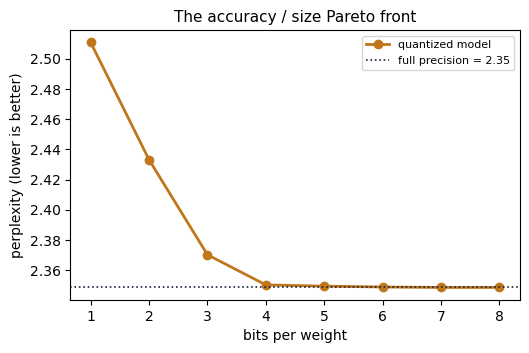

8-bit: perplexity 2.349   KL(p_full || p_quant) = 0.0000 nats
4-bit: perplexity 2.350   KL(p_full || p_quant) = 0.0009 nats
2-bit: perplexity 2.433   KL(p_full || p_quant) = 0.0348 nats
1-bit: perplexity 2.511   KL(p_full || p_quant) = 0.0713 nats
KV cache at fp16:  2.15 GB  (L=32, H=32, D=128, T=4096)
KV cache at int8:  1.07 GB  (L=32, H=32, D=128, T=4096)
KV cache at int4:  0.54 GB  (L=32, H=32, D=128, T=4096)


In [43]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL = "#17233F", "#C0761B", "#2C6E6A"

def perplexity_of(W):
    ids = [stoi[c] for c in corpus]; nll = 0.0
    for a, b in zip(ids, ids[1:]): nll += -np.log(softmax(W[a])[b])
    return np.exp(nll / (len(ids) - 1))

bits = list(range(1, 9))
ppx  = [perplexity_of(quantize(Wg, b, per_channel=True, axis=1)) for b in bits]   # Wg from Chapter 7
full = perplexity_of(Wg)

fig, ax = plt.subplots(figsize=(5.8, 3.5))
ax.plot(bits, ppx, "o-", color=AMBER, lw=2, label="quantized model")
ax.axhline(full, color=INK, ls=":", lw=1.2, label=f"full precision = {full:.2f}")
ax.set_xlabel("bits per weight"); ax.set_ylabel("perplexity (lower is better)")
ax.legend(fontsize=8); ax.set_title("The accuracy / size Pareto front", fontsize=11); plt.show()

def kl_full_vs(Wq):
    # belief fidelity: KL(p_full || p_quant), averaged over the four contexts
    kls = []
    for i in range(V):
        pf, pq = softmax(Wg[i]), softmax(Wq[i])
        kls.append(float(np.sum(pf * (np.log(pf + 1e-12) - np.log(pq + 1e-12)))))
    return float(np.mean(kls))

for b in [8, 4, 2, 1]:
    Wq = quantize(Wg, b, per_channel=True, axis=1)
    print(f"{b}-bit: perplexity {perplexity_of(Wq):.3f}   KL(p_full || p_quant) = {kl_full_vs(Wq):.4f} nats")
# the KV cache (Chapter 7) is the other place precision pays off at inference:
L, H, D, T = 32, 32, 128, 4096
for name, bytes_ in [("fp16", 2), ("int8", 1), ("int4", 0.5)]:
    gb = L * H * D * T * 2 * bytes_ / 1e9      # 2 = keys and values
    print(f"KV cache at {name:>4}: {gb:5.2f} GB  (L={L}, H={H}, D={D}, T={T})")

**Self-checks (Ch 10).** (a) With the repaired scale $s=1/3$ and $z=4$, compute the grid endpoints $s(q_{\min}-z)$ and $s(q_{\max}-z)$ and confirm they cover $[-1,1]$. (b) State the exact condition under which the half-step lemma does *not* apply to a point. (c) Why can a single outlier row ruin per-tensor quantization for every other row?

For *this toy* — a $4\times4$ bigram matrix under one per-row min/max fake quantizer, scored on its training corpus — perplexity is essentially flat from 8 bits down to about 4, then degrades sharply as the grid becomes too coarse. That shape is a real and useful intuition: more bits mean finer stairs and smaller error, with diminishing returns until the grid can no longer represent the weights at all.

(Three different questions hide here, so use three instruments. The training-corpus NLL is a paired, *in-sample sanity check* — the same contexts before and after rounding — and it can sit flat while every non-target probability drifts. *Belief fidelity* — does the quantized model still believe what the full-precision model believed? — is a divergence between the two output distributions, and the $\mathrm{KL}(p_{\text{full}}\|p_{\text{quant}})$ column in the sweep above measures exactly that. Deployment *quality* is a third question, answerable only on held-out data.)

Do **not** read this curve as "4-bit LLM inference is generally near-lossless" or "degradation begins below 4 bits." Those are empirical claims about real systems, and this cell establishes neither. Whether a given bit width is acceptable for a real model depends on: which tensors are quantized (weights vs activations vs KV cache), the quantizer type (affine/symmetric, per-tensor/per-channel/groupwise), calibration data, outlier handling, the kernel/hardware path, and a *held-out* evaluation — none of which this toy varies. The KV-cache byte counts below are a separate storage arithmetic (halving at int8, quartering at int4); quantizing the cache is its own scheme with its own accuracy question, not something the weight-precision knob does automatically.

**Where we stand.** The compression story is complete — weights (here, the trained bigram's) on a finite grid with a provable half-step guarantee, and a transformer cache whose bytes can be counted before buying the hardware.

**The forced move.** We can now build, train, decode from, name, and compress a language model. Token-likelihood training can generalize beyond its observed text and responses, but it has not directly learned from a label that ranks one candidate above another. The final gap is adding that comparative signal when judgments are easier to supply than ideal demonstrations. Doing so requires one more objective — and with it, the shape you have been tracking since Chapter 1 walks on stage one more time — next.

## 11 · Alignment, and the shape you have been tracking

Pretraining and supervised fine-tuning optimize token likelihood on broad text and curated responses, and they can generalize to sequences never shown verbatim. Their ordinary training examples do not, however, directly encode the pairwise observation *"this answer is better than that one."* Preferences are a different kind of supervision — comparisons between candidate outputs. When those comparisons are available, using them directly calls for a preference objective rather than pretending that likelihood models are replay machines. Deriving that objective is where the whole course converges.

### The objective, and why it is constrained

We want a policy $\pi_\theta$ over responses that earns high reward $r(y)$ (from human comparisons) — but *not* at any cost. Maximizing reward alone collapses the model onto the single highest-reward output, abandoning the fluent, general behavior that pretraining and fine-tuning bought; this is the degeneration that unconstrained reward optimization produces in practice. So we tether the aligned policy to a trusted **reference** $\pi_{\text{ref}}$ (the fine-tuned model) with a KL penalty, and maximize

$$
\max_{\pi}\ \Big\{\ \mathbb E_{y\sim\pi}[\,r(y)\,] \;-\; \beta\,\mathrm{KL}\!\big(\pi \,\|\, \pi_{\text{ref}}\big)\ \Big\}.
$$

Read the two terms: *pursue reward*, but *stay close to what you already are*, with $\beta$ setting the price of straying. Now solve it — and watch what falls out.

In [44]:
import numpy as np
from scipy.optimize import minimize
import warnings
np.set_printoptions(suppress=True)

# a handful of candidate responses, the reference policy over them (the SFT model),
# and a human-preference reward for each
responses = ["A", "B", "C", "D", "E"]
pi_ref = np.array([0.35, 0.25, 0.20, 0.15, 0.05])     # what the fine-tuned model outputs
reward = np.array([0.20, 1.00, 0.60, 1.50, 0.10])     # reward from human comparisons

def solve_kl_regularized(pi_ref, reward, beta):
    # maximize <pi, reward> - beta * KL(pi || pi_ref) over the simplex -- no closed form assumed
    def neg(pi):
        pi = np.clip(pi, 1e-12, 1)
        kl = np.sum(pi * np.log(pi / pi_ref))
        return -(pi @ reward - beta * kl)
    cons = ({"type": "eq", "fun": lambda p: p.sum() - 1},)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Values in x were outside bounds during a minimize step", category=RuntimeWarning)
        res = minimize(neg, pi_ref.copy(), bounds=[(1e-9, 1)] * len(reward),
                       constraints=cons, method="SLSQP", options={"ftol": 1e-12, "maxiter": 800})
    if not res.success:
        raise RuntimeError(f"SLSQP failed: {res.message}")
    return res.x

def gibbs_closed_form(pi_ref, reward, beta):
    w = pi_ref * np.exp(reward / beta)                 # pi_ref(y) * exp(r(y)/beta)
    return w / w.sum()

for beta in [2.0, 0.5, 0.1]:
    num = solve_kl_regularized(pi_ref, reward, beta)
    cf  = gibbs_closed_form(pi_ref, reward, beta)
    assert np.allclose(num, cf, atol=1e-5)
    print(f"beta={beta}:  numerical optimum {num.round(4)}   closed form {cf.round(4)}   max diff {np.abs(num-cf).max():.2e}")

beta=2.0:  numerical optimum [0.2688 0.2864 0.1876 0.2207 0.0365]   closed form [0.2688 0.2864 0.1876 0.2207 0.0365]   max diff 8.60e-09
beta=0.5:  numerical optimum [0.0855 0.3025 0.1087 0.4933 0.01  ]   closed form [0.0855 0.3025 0.1087 0.4933 0.01  ]   max diff 1.15e-07
beta=0.1:  numerical optimum [0.     0.0111 0.0002 0.9887 0.    ]   closed form [0.     0.0111 0.0002 0.9887 0.    ]   max diff 1.26e-07


The numerical optimizer and the closed form agree to tolerance, and the closed form is

$$
\boxed{\ \pi^\ast(y)\ \propto\ \pi_{\text{ref}}(y)\,\exp\!\big(r(y)/\beta\big)\ }
$$

**This is a Gibbs distribution.** It is the *exact* structure you first solved in Chapter 1 — maximize expected score plus an entropy-like term, and get $p\propto\exp(\text{score}/\text{temperature})$ — and met again in Chapter 4, where each attention row was that same problem over prefix positions. Here it appears a third time, at the largest scale in the system: over *whole responses*, with the reference policy as the base measure and $\beta$ as the temperature. The unlabeled flag planted in Chapter 1 has a name and a third home.

One optimization principle, three scales:

| appearance | competition is between… | temperature |
| --- | --- | --- |
| softmax head (Ch 1) | next tokens | $\tau = 1$ |
| attention (Ch 4) | prefix positions to read | $\tau = \sqrt{D}$ |
| alignment (Ch 11) | whole candidate responses | $\beta$ |

Every one of them is the same tension: *seek the high-scoring option, but do not collapse onto a hard argmax.* Sweep $\beta$ and watch that tension resolve, exactly as the temperature sweep did in Chapter 1 — the reader's first and last encounter with the same picture.

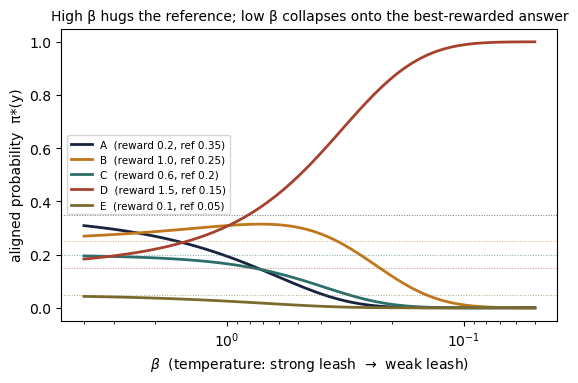

high beta (β=4):   [0.309 0.27  0.195 0.183 0.043]  ≈ reference [0.35 0.25 0.2  0.15 0.05]
low  beta (β=0.05): [0. 0. 0. 1. 0.]  -> all mass on D, the max-reward response


In [45]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL, RULE = "#17233F", "#C0761B", "#2C6E6A", "#CDC3AB"

betas = np.logspace(np.log10(4.0), np.log10(0.05), 60)
P = np.array([gibbs_closed_form(pi_ref, reward, b) for b in betas])   # (betas, responses)

cols = [INK, AMBER, TEAL, "#A6412E", "#7A6A2E"]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for i, name in enumerate(responses):
    ax.plot(betas, P[:, i], color=cols[i], lw=2, label=f"{name}  (reward {reward[i]}, ref {pi_ref[i]})")
    ax.axhline(pi_ref[i], color=cols[i], lw=0.7, ls=":", alpha=0.6)      # the reference value
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$\beta$  (temperature: strong leash  →  weak leash)")
ax.set_ylabel("aligned probability  π*(y)")
ax.legend(fontsize=7.5, loc="center left"); 
ax.set_title("High β hugs the reference; low β collapses onto the best-rewarded answer", fontsize=10)
plt.show()

print("high beta (β=4):  ", gibbs_closed_form(pi_ref, reward, 4.0).round(3), " ≈ reference", pi_ref)
print("low  beta (β=0.05):", gibbs_closed_form(pi_ref, reward, 0.05).round(3),
      " -> all mass on D, the max-reward response")

At high $\beta$ the aligned policy hugs the reference: at $\beta=4$ it is $[0.309,0.270,0.195,0.183,0.043]$ against the reference $[0.350,0.250,0.200,0.150,0.050]$ — visibly *closer* than at low $\beta$, though not identical; the precise statement is the limit $\pi^\ast\to\pi_{\text{ref}}$ as $\beta\to\infty$. At low $\beta$ the policy collapses onto response D, the highest reward. In between sits the useful regime: reshaped toward better answers while still fluent and general — the identical score-versus-entropy dial from Chapter 1's temperature plot, now steering an entire aligned model.

**A note on how this is trained in practice (DPO), stated in full.** Inverting the boxed Gibbs optimum gives $r(x,y)=\beta\log\frac{\pi^\ast(y\mid x)}{\pi_{\text{ref}}(y\mid x)}+\beta\log Z(x)$, but that inversion **alone is not a trainable objective** — it still contains the intractable prompt-dependent partition $Z(x)$. **Direct Preference Optimization (DPO)** closes the gap with a *preference model*: assume pairwise preferences follow Bradley–Terry, $\Pr[y^+\!\succ y^-]=\sigma\!\big(r(x,y^+)-r(x,y^-)\big)$. Substituting the inverted reward, the $\beta\log Z(x)$ terms **cancel** between $y^+$ and $y^-$, leaving a binary-cross-entropy loss in policy log-ratios with no explicit reward model:

$$
\mathcal L_{\mathrm{DPO}}(\theta)=-\,\mathbb E_{(x,y^+,y^-)}\!\left[\log\sigma\!\Big(\beta\log\tfrac{\pi_\theta(y^+\mid x)}{\pi_{\text{ref}}(y^+\mid x)}-\beta\log\tfrac{\pi_\theta(y^-\mid x)}{\pi_{\text{ref}}(y^-\mid x)}\Big)\right],\qquad \sigma(u)=\tfrac{1}{1+e^{-u}}.
$$

So DPO fits an *implicit* reward under an explicit preference model; it is not an assumption-free shortcut to the boxed optimum (Rafailov et al., 2023, arXiv:2305.18290). The objective it descends is still governed by the Gibbs solution above.

**Where we stand.** The core model is assembled and run end to end, with one tied parameter group optimized through the full stack; the course also trains and decodes a complete bigram, then names, compresses, and aligns the relevant objects — and the single mathematical structure underneath its output head, its attention, and its alignment has revealed itself to be one and the same. What remains is not more of the machine but the horizon around it: the architectures being proposed to relax its costs, and how to keep reading the field once the course ends.

## 12 · Beyond the transformer: reading a new architecture

New sequence-model architectures arrive constantly, each claiming to improve on or replace attention. You do not need to memorize them. You need one diagnostic, because every one of them is attacking the same two costs — and once you can name those costs, any paper reads as "which term are they cutting, and what do they pay for it?"

The transformer's two budgets, both of which we have already computed in this course:

- **Compute.** The dense score matrix is $(T,T)$ per layer per head, so attention costs $O(T^2)$ — it grows *quadratically* with context length (Chapter 4).
- **Memory (at inference).** The KV cache stores one key and value per layer, per head, per position: $O(L\,H\,D\,T)$ (Chapter 7).

Make the blowup concrete first — it is the pressure every alternative is responding to.

  context T     score entries/head    KV cache (fp16)
        512                262,144             0.3 GB
      2,048              4,194,304             1.1 GB
      8,192             67,108,864             4.3 GB
     32,768          1,073,741,824            17.2 GB
    131,072         17,179,869,184            68.7 GB


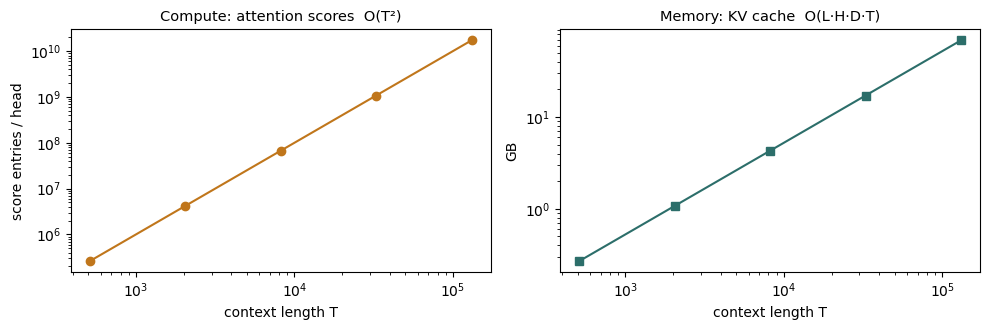

In [46]:
import numpy as np
import matplotlib.pyplot as plt
INK, AMBER, TEAL, RED = "#17233F", "#C0761B", "#2C6E6A", "#A6412E"

Ts = np.array([512, 2048, 8192, 32768, 131072])       # context lengths
L, H, D = 32, 32, 128                                  # layers, heads, per-head dim
scores = Ts.astype(float) ** 2                         # (T,T) score entries per layer per head
cache_gb = L * H * D * Ts * 2 * 2 / 1e9                # K and V, fp16 (2 bytes each)

print(f"{'context T':>11} {'score entries/head':>22} {'KV cache (fp16)':>18}")
for t, s, c in zip(Ts, scores, cache_gb):
    print(f"{t:>11,} {int(s):>22,} {c:>15.1f} GB")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].loglog(Ts, scores, "o-", color=AMBER); ax[0].set_title("Compute: attention scores  O(T²)", fontsize=10.5)
ax[0].set_xlabel("context length T"); ax[0].set_ylabel("score entries / head")
ax[1].loglog(Ts, cache_gb, "s-", color=TEAL); ax[1].set_title("Memory: KV cache  O(L·H·D·T)", fontsize=10.5)
ax[1].set_xlabel("context length T"); ax[1].set_ylabel("GB")
plt.tight_layout(); plt.show()

At 128k tokens the score matrix has ~17 billion entries per head and the cache runs to tens of gigabytes. That is the wall. Now read the three main families of alternative as *each relaxing one specific term*:

- **Sparse / local attention** shrinks the *score graph*. Instead of every position reading every earlier one, each reads a window of size $w$ (or a fixed sparse pattern), turning $O(T^2)$ into $O(T\,w)$. *Pays:* long-range dependencies must hop through many layers, or are lost.
- **Grouped-query / multi-query attention (GQA / MQA)** shrinks the *cache*. Query heads stay separate but share key/value streams across groups: $G$ groups give cache $O(L\,G\,D\,T)$, with $G=H$ recovering full multi-head attention and $G=1$ being MQA. *Pays:* slightly less expressive key/value routing.
- **Linear attention / state-space models (SSMs)** remove the explicit $(T,T)$ matrix entirely, replacing it with a *recurrence* that carries a fixed-size state — $O(T)$ compute and a constant-size state instead of a growing cache. *Pays:* the trade is a **growing exact cache versus a fixed-size compressed state**. Full attention keeps every cached key/value and lets each new query address them directly; a fixed-size recurrent state must compress history and may discard task-relevant information. (Even full attention is not a "lossless recall" guarantee by theorem — its output is a softmax-weighted mixture through finite-dimensional projections, which can be rank-deficient — but the *growing exact state* is what a fixed recurrent state gives up.)

Plot the term each one bends.

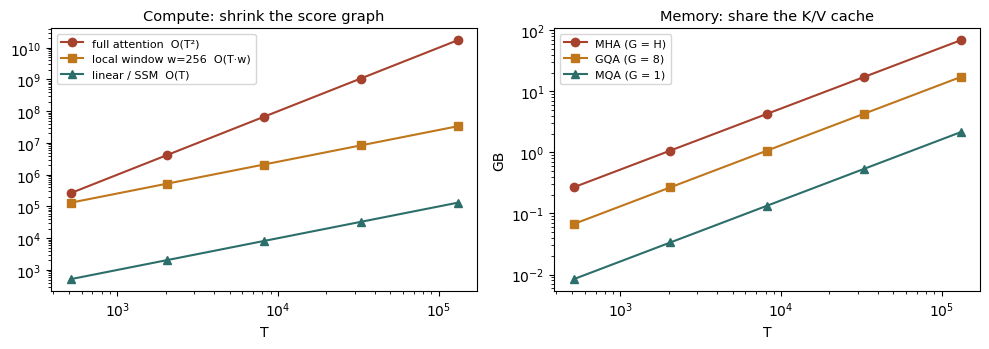

at T = 131,072:
   local vs full compute : 512x less
   MQA vs MHA cache      : 32x less


In [47]:
import numpy as np
import matplotlib.pyplot as plt
AMBER, TEAL, RED = "#C0761B", "#2C6E6A", "#A6412E"

w, G = 256, 8
full_c, local_c, linear_c = Ts.astype(float) ** 2, Ts * w, Ts.astype(float)         # compute
mha_c  = L * H * D * Ts * 2 * 2 / 1e9                                                # cache GB
gqa_c  = L * G * D * Ts * 2 * 2 / 1e9
mqa_c  = L * 1 * D * Ts * 2 * 2 / 1e9

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].loglog(Ts, full_c, "o-", color=RED,   label="full attention  O(T²)")
ax[0].loglog(Ts, local_c, "s-", color=AMBER, label=f"local window w={w}  O(T·w)")
ax[0].loglog(Ts, linear_c, "^-", color=TEAL, label="linear / SSM  O(T)")
ax[0].set_title("Compute: shrink the score graph", fontsize=10.5); ax[0].set_xlabel("T"); ax[0].legend(fontsize=8)
ax[1].loglog(Ts, mha_c, "o-", color=RED,   label="MHA (G = H)")
ax[1].loglog(Ts, gqa_c, "s-", color=AMBER, label=f"GQA (G = {G})")
ax[1].loglog(Ts, mqa_c, "^-", color=TEAL, label="MQA (G = 1)")
ax[1].set_title("Memory: share the K/V cache", fontsize=10.5); ax[1].set_xlabel("T"); ax[1].set_ylabel("GB"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"at T = {Ts[-1]:,}:")
print(f"   local vs full compute : {full_c[-1]/local_c[-1]:.0f}x less")
print(f"   MQA vs MHA cache      : {mha_c[-1]/mqa_c[-1]:.0f}x less")

| Family | Budget it cuts | Mechanism | What it pays |
| --- | --- | --- | --- |
| Sparse / local | compute $O(T^2)\to O(Tw)$ | restrict which positions attend | long-range reach |
| GQA / MQA | cache $O(LHDT)\to O(LGDT)$ | share K/V across heads | K/V expressiveness |
| Linear / SSM | both $\to O(T)$, constant state | recurrence instead of the $(T,T)$ matrix | growing exact cache vs fixed compressed state |

That table is the reading method. It is not a taxonomy to memorize — it is a question to ask any new architecture: *which line does it bend, and what does it give up to bend it?* The answer places the paper immediately, no matter how unfamiliar its notation.

**Where we stand.** Every object the course promised is on the table — a transformer assembled and run end to end, training and decoding disciplines, compression and alignment each derived and demonstrated on its own toy — and the design is now *placed*: one point in a space whose axes (compute, cache, exactness of memory) you can read off any new paper.

**The forced move.** There is none — this is the frontier, where the forcing runs out and judgment begins. Which brings us to the only thing left to hand over: how to keep reading it.

### A reading method for any new architecture (and distinct directions around it)

The table is a diagnostic, not a taxonomy. For **any** new sequence-model paper, ask: (1) what objective and data does it use? (2) which budget or capability does it target? (3) what mechanism changes? (4) what does it pay? (5) what smallest controlled experiment could falsify the headline claim? State the metric, baseline, and fixed resource before believing the abstract.

Do not collapse different directions into the quadratic-attention story:

- **Retrieval / external memory** searches an external corpus and inserts selected evidence into the model input. It externalizes corpus access and can improve freshness or evidence selection, but the retrieved passages still consume context. Its failures include missing documents, chunking/query/ranking errors, context packing, and generation that ignores evidence.
- **World-model / JEPA-style objectives** predict learned representations or latent structure rather than next tokens. They primarily target sample efficiency, planning, and representation quality; evaluation is less direct, and they may still use a transformer with quadratic attention. They are not inherently a context-scaling method.

### Systems around the base language model

| System piece | What changes | Distinct failure / metric |
| --- | --- | --- |
| Prompting / in-context learning | input sequence; weights stay fixed | formatting, order, irrelevant context |
| **Sparse retrieval** | lexical term-weighted search (for example BM25) | misses paraphrases or semantic matches |
| **Dense retrieval** | learned query/document embeddings | domain drift, opaque similarity, hard-to-debug misses |
| **Tool use** | an external function returns a new observation during inference | schema, arguments, permissions, side effects |
| **Persistent memory** | state survives across interactions | stale data, provenance, privacy, state management |
| Serving | prefill builds KV state; decode extends it token by token | latency, throughput, memory; continuous batching and paged KV storage manage variable requests |

RAG composes retrieval with generation: question $\to$ retriever $\to$ passages $\to$ LM context $\to$ answer. Evaluation must localize failures across that chain and match the claim: held-out NLL measures likelihood, retrieval metrics measure evidence selection, task metrics measure the requested behavior, and serving metrics measure latency/throughput/memory.


## 13 · How to keep going

This is not a summary — it is a practice, and a send-off.

The single transferable skill in this subject is not memorizing formulas. It is moving fluently between four views of the **same** object:

1. a plain **sentence** — "position $t$ may attend only to positions up to $t$";
2. a typed **mathematical map** — $M_{t,s}=0$ if $s\le t$, else $-\infty$, added before softmax;
3. a **tensor shape** — $(T,T)$;
4. a line of **code** — the mask you build and add.

Whenever you meet a new idea, write down all four. The one you cannot fill in is precisely the thing you do not yet understand. Here are the four views of one object, with the fourth *executed*, so the sentence is not asserted but verified.

In [48]:
import numpy as np
# FOUR VIEWS OF ONE OBJECT — the causal mask
# (1) sentence: a position may attend to itself and the past, never the future
# (2) math:     M[t,s] = 0 for s<=t, -inf for s>t, added to scores before softmax
# (3) shape:    (T, T)
# (4) code, run:
T = 5
M = np.triu(np.full((T, T), -np.inf), k=1)          # the mask
weights = softmax_rows(np.zeros((T, T)) + M)         # softmax of the mask alone (flat scores)

print("attention from the mask alone (uniform over the allowed prefix):")
print(weights.round(3))
# 0-based row index t allows columns s <= t, i.e. t+1 positions (rows below have 1,2,3,4,5 entries).
print("\nRow t (0-based) spreads over exactly t+1 positions and is zero on the future.")
print("nonzero entries per row:", (weights > 0).sum(axis=1).tolist(), " = [1, 2, 3, 4, 5]")
print("The sentence, the math, the shape, and the code are one object — now confirmed by running it.")

attention from the mask alone (uniform over the allowed prefix):
[[1.    0.    0.    0.    0.   ]
 [0.5   0.5   0.    0.    0.   ]
 [0.333 0.333 0.333 0.    0.   ]
 [0.25  0.25  0.25  0.25  0.   ]
 [0.2   0.2   0.2   0.2   0.2  ]]

Row t (0-based) spreads over exactly t+1 positions and is zero on the future.
nonzero entries per row: [1, 2, 3, 4, 5]  = [1, 2, 3, 4, 5]
The sentence, the math, the shape, and the code are one object — now confirmed by running it.


A working loop, once you internalize the four views: read a section without running it; **predict** every shape and output; run it; then **break one line on purpose** and explain the failure before you fix it. That last step is not vandalism — in this course it has *been* the method. Nearly every chapter opened by building the obvious thing and watching it break: the unsmoothed count table that called a legal string impossible, the positionless model that could not tell `"ca"` from `"ac"`, greedy decoding locked in a loop, per-tensor quantization crushing the fine-scale weights. The break is where the next idea comes from, and you can generate that experience yourself, on any claim, by deleting a term and running the cell.

One honest caveat about the code, so the method stays honest: the cells are **top-to-bottom runnable in one shared notebook state**, not independently self-contained. Later cells depend on earlier definitions (`softmax`, `stoi`, `corpus`, `pairs`, `Wg`, and the end-to-end model), so run the notebook in order; running a single quantization or generation cell in a fresh kernel will `NameError` until the earlier chapters have executed.

### One more map: this course is a slice of NLP, not all of it

A last honesty. Fluent next-token generation is *not* evidence that a model does every language task well. Around the core LM sit task families this course did not build: **structured prediction** (tagging, parsing), **information extraction** (entities, relations, events), **semantic roles and coreference**, **discourse and summarization**, **speech** (recognition/synthesis), and **agentic loops** (tool use, planning, verification). Each has its own inputs, metrics, and failure modes, and each is a place where a confident-sounding generation can be wrong in a way perplexity never sees. The transferable skill you built — move fluently between sentence, math, shape, and code, and break a claim to understand it — is exactly what lets you pick any of these up next.

---

Look back at the whole arc. We began with one question — *given a prefix, what distribution governs the next token?* — and refused the cheap answer, because an unsmoothed count table cannot generalize to the unseen. Everything after was machinery forced into existence by a visible failure of what came before: scores needed a bridge to probabilities (softmax), which needed a bridge to a loss (cross-entropy) and to motion (the gradient $p-e_y$); tokens needed coordinates (embeddings), whose order-blindness (for the *unmasked* part of the machine) motivated a way for positions to read each other (attention) and a direct signal of *where* (position embeddings); a single head's convex-mixing limit motivated projections and new features (the MLP), and depth motivated the residual path; random weights forced training; distributions forced a decoding policy; pairwise judgments motivated preference alignment.

And underneath three of those steps — the output head, the attention weights, the aligned policy — sat one and the same structure: *seek the high-scoring option, but do not collapse onto a hard choice.* The Gibbs distribution, at three scales. That recurrence was the real subject all along; the flag planted quietly in Chapter 1 came home in Chapter 11.

You now hold the machine, the reason each part had to exist, and the one principle that keeps returning. What separates this toy from a frontier model is **not only scale**. Scale — more data, more parameters, more compute — is necessary, and this notebook is deliberately tiny. But frontier quality and behavior also depend on tokenizer and data construction, architecture details, training objectives and optimization, post-training (SFT and preference alignment), retrieval and tool systems, evaluation, serving, and safety/reliability — several of which this course itself introduced. The *core mathematical contracts* are the ones you just built; the rest of the distance is engineering and science layered around them.

---
*A merged union of two sources: the build-it-till-it-breaks narrative of `99c` and the derivations-first rigor of `99_complete_college_level_walkthrough.ipynb`. All fourteen chapters (0–13) are present; the build chapters each open with a question, build the naive answer in runnable `numpy`, watch it break, and derive the repair as the thing that had to come next (Chapter 9 is deliberately a dictionary, Chapter 13 a send-off). Every exploration cell runs on `numpy`/`scipy`/`matplotlib` alone — no repository, framework, or GPU — top-to-bottom in one shared kernel, so any claim can be broken by deleting a line and re-running.*

*Recomposed at iteration 9 for pedagogical movement (LEDGER F-034–F-044): structure and voice only — every audited claim retains its converged strength.*